# GKG 기반 GPR 대체 지수 산출 (황규 파트)
## 지정학적 위기 시 비트코인은 디지털 금인가? — 캡스톤디자인

---

### 작업 흐름

```
Step 0  라이브러리 설치
Step 1  전역 설정
Step 2  CSV 로드 + 데이터 이해
Step 3  데이터 전처리
Step 4  공식 GPR 로드
Step 5  GPR 대체 지수 5종 산출
        - F1: 단순 일평균 tone 역전 지수
        - F2: 극성 가중 tone 지수
        - F3: 보도량×tone 복합 지수
        - F4: 부정 비율 기반 지수
        - F5: 28일 지수가중 이동평균 지수
Step 6  공식 GPR과 상관관계 분석
Step 7  시각화
Step 8  결과 저장
```

### 입력 파일

| 파일명 | 이벤트 | 기준일 |
|---|---|---|
| `hormuz_crisis.csv` | 호르무즈 해협 위기 | 2019-06-13 |
| `soleimani_assassination.csv` | 솔레이마니 암살 | 2020-01-03 |
| `russia_ukraine_invasion.csv` | 러-우 전쟁 | 2022-02-24 |
| `israel_hamas.csv` | 이스라엘-하마스 전쟁 | 2023-10-07 |
| `israel_iran.csv` | 이스라엘-이란 충돌 | 2024-04-01 |
| `us_israel_iran.csv` | 이란 전쟁 | 2026-02-28 |



---
## Step 0. 라이브러리 설치

In [1]:
!pip install pandas numpy matplotlib scipy openpyxl statsmodels --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Step 1. 전역 설정

In [4]:
import pandas as pd
# import gcsfs - 구글 클라우드용
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from scipy import stats
import warnings, os

warnings.filterwarnings('ignore')

import matplotlib, platform
if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')
matplotlib.rc('axes', unicode_minus=False)

print('라이브러리 로드 완료')
print(f'pandas {pd.__version__} / numpy {np.__version__}')

라이브러리 로드 완료
pandas 2.2.3 / numpy 2.2.4


In [11]:
# --- 전역 설정 (GCS 연동 버전) ---

# 이벤트 및 날짜 정의
EVENT_DATES = {
    'hormuz_crisis'          : '2019-06-13',
    'soleimani_assassination': '2020-01-03',
    'russia_ukraine_war': '2022-02-24',
    'israel_hamas_war'           : '2023-10-07',
    'israel_iran'            : '2024-04-01',
    'us_israel_iran'         : '2026-02-28',
}

EVENT_LABELS = {
    'hormuz_crisis'          : '호르무즈 위기',
    'soleimani_assassination': '솔레이마니 암살',
    'russia_ukraine_war': '러-우 전쟁',
    'israel_hamas_war'           : '이스라엘-하마스',
    'israel_iran'            : '이스라엘-이란 충돌',
    'us_israel_iran'         : '이란 전쟁',
}

# --- GPR 데이터 설정 (주피터랩 로컬 경로) ---
GPR_FILE = 'data_gpr_daily_recent.csv' 

COLORS = {
    'hormuz_crisis'          : '#E76F51',
    'soleimani_assassination': '#2A9D8F',
    'russia_ukraine_war': '#457B9D',
    'israel_hamas_war'           : '#8338EC',
    'israel_iran'            : '#E9C46A',
    'us_israel_iran'         : '#F4A261',
}

# 분석에 사용할 주요 테마 리스트 (GPR 계산 시 활용 가능)
GEO_THEMES = [
    'ARMEDCONFLICT', 'CRISISLEX_T03_ARMED-CONFLICT',
    'WB_635_PEACE_AND_SECURITY', 'WB_2432_FRAGILITY_CONFLICT_AND_VIOLENCE',
    'WB_2470_PEACE_OPERATIONS_AND_CONFLICT_MANAGEMENT',
    'WB_2490_NATIONAL_PROTECTION_AND_SECURITY',
    'EPU_CATS_NATIONAL_SECURITY',
    'SANCTIONS', 'MILITARY', 'TAX_FNCACT_MILITARY',
    'MARITIME_INCIDENT', 'TERROR', 'KILL',
    'CRISISLEX_CRISISLEXREC', 'CRISISLEX_C07_SAFETY',
    'DRONES', 'CYBER_ATTACK',
]

print('전역 설정 완료')
print(f'GPR 파일 경로: {GPR_FILE}')

전역 설정 완료
GPR 파일 경로: data_gpr_daily_recent.csv


# 전쟁 분할 전처리 진행

## 호르무즈, 솔레이마니

---
### Step 2. CSV 로드 + 데이터 이해

| 컬럼 | 설명 | 비고 |
|---|---|---|
| `event_timestamp` | 기사 수집 시각 (UTC) | GDELT 15분 단위 |
| `date` | YYYYMMDD 날짜 | 일별 집계 키 |
| `url` | 기사 URL | 중복 제거 기준 |
| `tone_score` | 전체 어조 | 음수=부정, 양수=긍정 |
| `positive_score` | 긍정 단어 비율 | V2Tone[1] |
| `negative_score` | 부정 단어 비율 | V2Tone[2] |
| `polarity` | 감정 강도 (pos+neg) | V2Tone[3] |
| `themes` | GDELT 자동 분류 태그 | `;`로 구분 |

In [4]:
# 1. GCS 파일 시스템 클라이언트 생성 (fs 정의)
fs = gcsfs.GCSFileSystem()

# 2. 필요한 컬럼 리스트 정의
cols_to_use = [
    'event_timestamp', 'event_date', 'url', 'tone_score', 
    'positive_score', 'negative_score', 'polarity', 'themes'
]

all_war_data = {}
war_list = ['hormuz_crisis', 'soleimani_assassination']

# 'israel_hamas_war', 'israel_iran', 'us_israel_iran'
for war in war_list:
    # 각 버킷 내의 파일 패턴 설정 (실제 파일 이름에 따라 _ 또는 - 확인 필요)
    path = f'gs://{war}/{war}_*'  
    files = fs.glob(path)
    
    if files:
        # read_csv 시 usecols를 사용하여 필요한 컬럼만 메모리에 로드합니다.
        try:
            temp_df = pd.concat(
                [pd.read_csv(f"gs://{f}", usecols=cols_to_use) for f in files], 
                ignore_index=True
            )
            if 'event_date' in temp_df.columns:
                temp_df.rename(columns={'event_date': 'date'}, inplace=True)
            temp_df['event_label'] = war
            
            all_war_data[war] = temp_df
            print(f"✅ {war} 로드 완료: {len(temp_df)} 행")
        except Exception as e:
            print(f"❌ {war} 로드 중 오류 발생: {e}")

# 3. 모든 전쟁 데이터를 하나의 거대한 데이터프레임으로 통합
if all_war_data:
    total_war_df = pd.concat(all_war_data.values(), ignore_index=True)
    total_war_df = total_war_df.sort_values(by='event_timestamp', ascending=True).reset_index(drop=True)
    print(f"\n🚀 최종 통합 완료! 전체 행 개수: {len(total_war_df)}")
    display(total_war_df.head())
else:
    print("로드된 데이터가 없습니다.")

✅ hormuz_crisis 로드 완료: 348459 행
✅ soleimani_assassination 로드 완료: 610541 행

🚀 최종 통합 완료! 전체 행 개수: 959000


,event_timestamp,date,url,tone_score,positive_score,negative_score,polarity,themes,event_label
0,2019-01-01 00:00:00 UTC,2019-01-01,https://www.theburningplatform.com/2018/12/31/...,-8.836256,2.527898,11.364154,13.892052,"EPU_CATS_MONETARY_POLICY,9632;EPU_CATS_MONETAR...",hormuz_crisis
1,2019-01-01 00:00:00 UTC,2019-01-01,https://www.theage.com.au/world/europe/echoes-...,-4.384724,1.414427,5.799151,7.213579,"TAX_FNCACT_DEPUTY,197;TAX_FNCACT_DEPUTY,2658;T...",hormuz_crisis
2,2019-01-01 00:00:00 UTC,2019-01-01,https://hamodia.com/2018/12/31/iran-decks-elit...,1.775148,3.550296,1.775148,5.325444,"TAX_MILITARY_TITLE_ADMIRAL,361;TAX_FNCACT_ADMI...",hormuz_crisis
3,2019-01-01 00:15:00 UTC,2019-01-01,http://www.lassennews.com/why-are-we-allowing-...,-6.213592,2.912621,9.126214,12.038835,"TERROR,3551;WB_2451_REBELS_GUERRILLAS_AND_INSU...",hormuz_crisis
4,2019-01-01 00:15:00 UTC,2019-01-01,https://www.worldoil.com/news/2018/12/31/oil-s...,-4.861111,0.868056,5.729167,6.597222,"ARMEDCONFLICT,2204;EPU_CATS_NATIONAL_SECURITY,...",hormuz_crisis


In [6]:
# ── 데이터 기본 탐색 (통합 데이터용) ─────────────────────────────────────

if 'total_war_df' in locals() and not total_war_df.empty:
    print(f'▶ 통합 데이터 탐색 진행\n')
    
    print('기간:', total_war_df["date"].min(), '~', total_war_df["date"].max())
    print('전체 행수:', len(total_war_df))
    print()
    
    print('결측치 합계:')
    print(total_war_df.isnull().sum())
    
    print('\n수치형 컬럼 기술통계:')
    # 분석에 필요한 핵심 수치 컬럼들만 요약
    stats_cols = ['tone_score', 'positive_score', 'negative_score', 'polarity']
    display(total_war_df[stats_cols].describe().round(3))
else:
    print('탐색할 데이터프레임(total_war_df)이 존재하지 않습니다.')

▶ 통합 데이터 탐색 진행

기간: 2019-01-01 ~ 2021-01-27
전체 행수: 959000

결측치 합계:
event_timestamp    0
date               0
url                0
tone_score         0
positive_score     0
negative_score     0
polarity           0
themes             0
event_label        0
dtype: int64

수치형 컬럼 기술통계:


,tone_score,positive_score,negative_score,polarity
count,959000.000,959000.000,959000.000,959000.000
mean,-3.973,2.057,6.030,8.087
std,2.723,1.092,2.266,2.289
min,-31.579,0.000,0.000,0.000
25%,-5.618,1.328,4.505,6.540
50%,-3.922,1.922,5.880,7.937
75%,-2.273,2.626,7.368,9.459
max,17.204,17.921,31.579,35.000


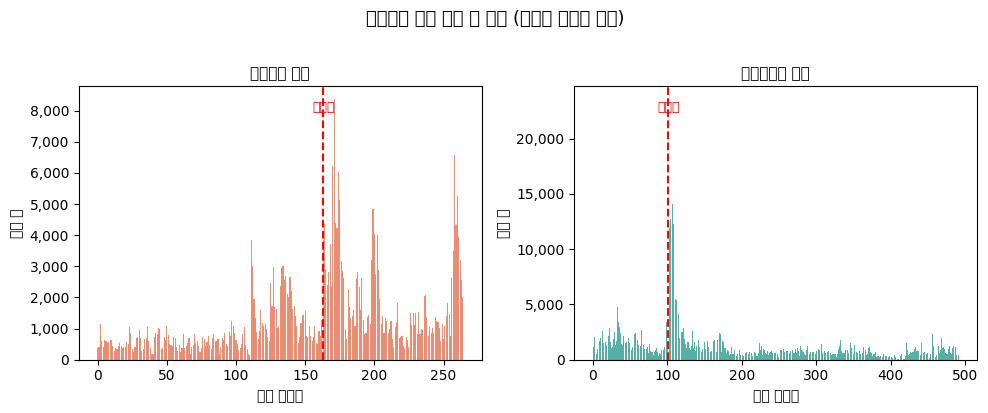

✅ 저장 완료: 01_raw_article_count.png


In [7]:
# ── 이벤트별 일별 기사 수 분포 (발발일 점선 추가) ───────────────────────────────

if all_war_data:
    n_raw = len(all_war_data)
    fig, axes = plt.subplots(1, n_raw, figsize=(5 * n_raw, 4))
    if n_raw == 1:
        axes = [axes]
    
    for ax, (event, df) in zip(axes, all_war_data.items()):
        # 1. 일별 기사 수 집계 및 정렬
        daily_cnt = df.groupby('date').size().sort_index()
        dates_list = daily_cnt.index.tolist() # 날짜 리스트 추출
        
        # 2. 바 차트 그리기
        ax.bar(range(len(daily_cnt)), daily_cnt.values,
               color=COLORS.get(event, 'steelblue'), alpha=0.8)
        
        # 3. [추가] EVENT_DATES에 설정된 날짜에 세로 점선 그리기
        event_origin_date = EVENT_DATES.get(event)
        
        if event_origin_date in dates_list:
            # 해당 날짜가 리스트의 몇 번째 인덱스인지 확인
            event_idx = dates_list.index(event_origin_date)
            
            # 세로 점선 추가 (vlines)
            ax.axvline(x=event_idx, color='red', linestyle='--', linewidth=1.5, label='발발일')
            
            # 점선 옆에 '발발일' 텍스트 추가 (선택 사항)
            ax.text(event_idx, ax.get_ylim()[1]*0.9, '발발일', color='red', 
                    fontsize=9, fontweight='bold', ha='center', va='bottom')

        # 4. 차트 꾸미기
        ax.set_title(EVENT_LABELS.get(event, event), fontsize=11)
        ax.set_xlabel('날짜 인덱스')
        ax.set_ylabel('기사 수')
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
            
    plt.suptitle('이벤트별 일별 기사 수 분포 (발발일 기준선 추가)', fontsize=13, y=1.02)
    plt.tight_layout()

    plt.savefig('01_raw_article_count.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ 저장 완료: 01_raw_article_count.png')
else:
    print("분석할 데이터(all_war_data)가 없습니다.")

---
### Step 3. 데이터 전처리

1. **중복 제거** — URL 기준
2. **결측치 처리** — tone 컬럼 NA 제거, 텍스트 컬럼 빈 문자열 대체
3. **이상값 처리** — |tone_score| > 20 제거
4. **지정학 테마 필터** — GEO_THEMES 태그 포함 기사만 유지
5. **`_date` 파생 컬럼** — timezone-naive datetime
6. **최소 기사 수 필터** — 하루 5건 미만 날짜 제거

In [11]:
MIN_DAILY_COUNT    = 5
TONE_OUTLIER_BOUND = 20

def has_geo_theme(themes_str):
    if pd.isna(themes_str) or themes_str == '':
        return False
    return any(tag in themes_str for tag in GEO_THEMES)

def preprocess(df, event_name):
    log = {'event': event_name, 'raw': len(df)}
    df  = df.copy()

    # ① 중복 제거
    df = df.drop_duplicates(subset=['url'])
    log['after_dedup'] = len(df)

    # ② tone 결측 제거
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity'])
    log['after_tone_na'] = len(df)

    # ③ 이상값 제거
    df = df[df['tone_score'].abs() <= TONE_OUTLIER_BOUND]
    log['after_outlier'] = len(df)

    # ④ 텍스트 결측 → 빈 문자열
    for col in ['themes']:
        df[col] = df[col].fillna('')

    # ⑤ _date 파생 컬럼
    df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])
    df['_date'] = df['event_timestamp'].dt.tz_convert(None).dt.normalize()

    # ⑥ 지정학 테마 필터
    df = df[df['themes'].apply(has_geo_theme)]
    log['after_geo_filter'] = len(df)

    # ⑦ 최소 기사 수 필터
    daily_cnt   = df.groupby('_date').size()
    valid_dates = daily_cnt[daily_cnt >= MIN_DAILY_COUNT].index
    df = df[df['_date'].isin(valid_dates)]
    log['after_min_count'] = len(df)
    log['valid_days']      = df['_date'].nunique()

    return df, log

clean_dfs = {}
logs = []
print('▶ 데이터 전처리\n')
header = (f'{"이벤트":<30} {"raw":>8} {"중복제거":>8} '
          f'{"이상값":>8} {"지정학":>8} {"최소건수":>8} {"유효일":>6}')
print(header)
print('-' * len(header))
for label, group_df in total_war_df.groupby('event_label'):
    # group_df는 해당 라벨에 속하는 데이터들만 모인 데이터프레임입니다.
    cleaned, log = preprocess(group_df, label)
    
    # 2. 결과 저장
    clean_dfs[label] = cleaned
    logs.append(log)
    
    # 3. 로그 출력 (기존 포맷 유지)
    print(f"{label:<30} "
          f"{log['raw']:>8,} {log['after_dedup']:>8,} "
          f"{log['after_outlier']:>8,} {log['after_geo_filter']:>8,} "
          f"{log['after_min_count']:>8,} {log['valid_days']:>6}")

# 결과 요약
preprocess_log_df = pd.DataFrame(logs)
print(f'\n✨ 전처리 완료: {len(clean_dfs)}개 이벤트')

▶ 데이터 전처리

이벤트                                 raw     중복제거      이상값      지정학     최소건수    유효일
----------------------------------------------------------------------------------
hormuz_crisis                   348,459  348,459  348,453  348,453  348,453    265
soleimani_assassination         610,541  610,541  610,439  610,439  610,439    492

✨ 전처리 완료: 2개 이벤트


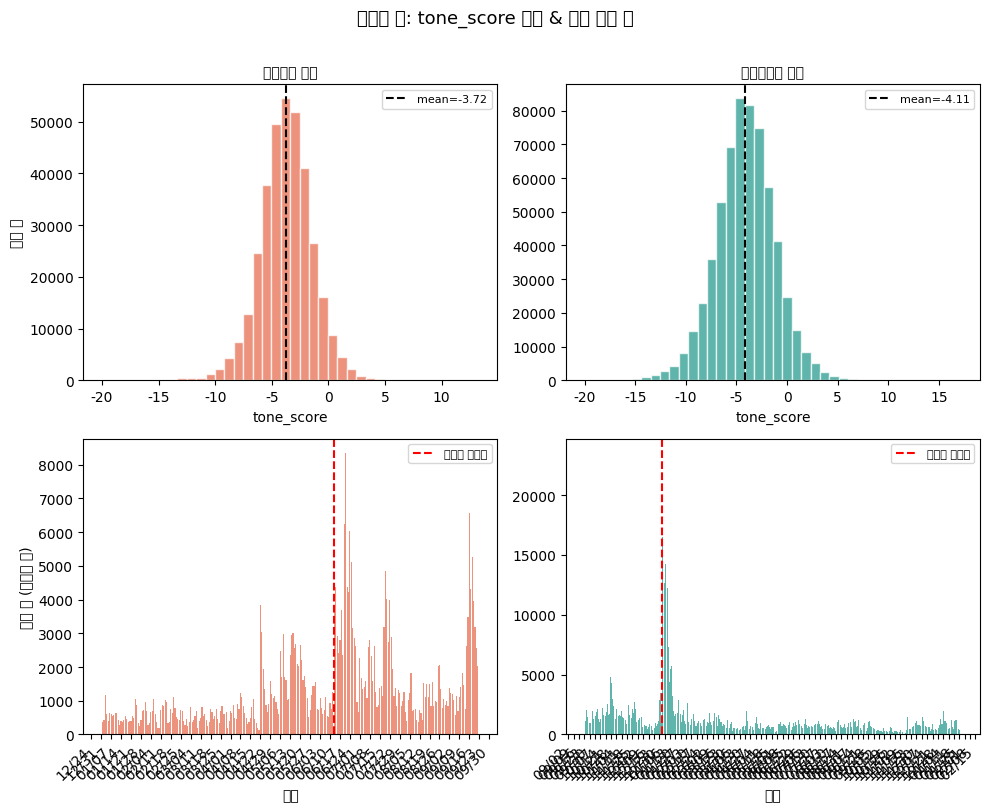

저장: 02_preprocessed_overview.png


In [12]:
if clean_dfs:
    n_ev = len(clean_dfs)
    fig, axes = plt.subplots(2, n_ev, figsize=(5 * n_ev, 8), squeeze=False)
    for col_i, (event, df) in enumerate(clean_dfs.items()):
        color = COLORS.get(event, 'steelblue')
        ax0 = axes[0, col_i]
        ax0.hist(df['tone_score'], bins=40, color=color,
                 alpha=0.75, edgecolor='white')
        ax0.axvline(df['tone_score'].mean(), color='black', lw=1.5, ls='--',
                    label=f"mean={df['tone_score'].mean():.2f}")
        ax0.set_title(EVENT_LABELS.get(event, event), fontsize=10)
        ax0.set_xlabel('tone_score')
        ax0.legend(fontsize=8)
        if col_i == 0:
            ax0.set_ylabel('기사 수')

        ax1 = axes[1, col_i]
        daily_cnt = df.groupby('_date').size()
        event_dt  = pd.Timestamp(EVENT_DATES[event])
        ax1.bar(daily_cnt.index, daily_cnt.values, color=color, alpha=0.75)
        ax1.axvline(event_dt, color='red', lw=1.5, ls='--', label='이벤트 기준일')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax1.set_xlabel('날짜')
        ax1.legend(fontsize=8)
        if col_i == 0:
            ax1.set_ylabel('기사 수 (전처리 후)')

    plt.suptitle('전처리 후: tone_score 분포 & 일별 기사 수', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('02_preprocessed_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 02_preprocessed_overview.png')

---
### Step 5. GPR 대체 지수 5종 산출

| 공식 | 이름 | 수식 | 참고 문헌 |
|---|---|---|---|
| F1 | 단순 일평균 tone 역전 | `−mean(tone)` | Caldara & Iacoviello 2022 |
| F2 | 극성 가중 tone | `−Σ(tone×polarity)/Σ(polarity)` | BBVA Research 2025 |
| F3 | 보도량×tone 복합 | `−mean(tone) × log(1+N)` | BNP Paribas AM 2022 |
| F4 | 부정 비율 기반 | `neg/(pos+neg)` | Caldara 원본 정신 |
| F5 | 28일 지수가중 이동평균 | F2에 기하 가중 MA 적용 | BBVA Monitor |

In [16]:
def compute_gpr_indices(df, event_name):
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity']).copy()

    # BUG-4 수정 완료
    df['tone_x_polarity'] = df['tone_score'] * df['polarity']

    agg = df.groupby('_date').agg(
        N                   = ('tone_score',      'count'),
        mean_tone           = ('tone_score',      'mean'),
        sum_tone_x_polarity = ('tone_x_polarity', 'sum'),
        sum_polarity        = ('polarity',         'sum'),
        mean_pos            = ('positive_score',  'mean'),
        mean_neg            = ('negative_score',  'mean'),
    ).copy()
    
    # ---------------------------------------------------------
    # [핵심] 보도량 상대적 정규화 (Relative Scaling)
    # ---------------------------------------------------------
    avg_n = agg['N'].mean()
    # 절대적 숫자 N 대신, 해당 이벤트 평균 대비 몇 배나 터졌는지(relative_N)를 사용
    agg['relative_N'] = agg['N'] / avg_n
    agg['coverage_scaled'] = np.log1p(agg['relative_N'])
    
    # F1: 단순 평균 톤 (역전)
    agg['F1_raw'] = -agg['mean_tone']

    # F2: 극성 가중 평균
    agg['F2_raw'] = np.where(
        agg['sum_polarity'] > 0,
        -agg['sum_tone_x_polarity'] / agg['sum_polarity'],
        np.nan)

    # F3: 상대적 보도량 복합 지수 (중복 계산 제거됨)
    agg['F3_raw'] = -agg['mean_tone'] * agg['coverage_scaled']

    # F4: 부정 비율
    denom = agg['mean_pos'] + agg['mean_neg']
    agg['F4_raw'] = np.where(denom > 1e-6, agg['mean_neg'] / denom, np.nan)

    # F5: F2 기반 28일 EWMA
    r, WND = 0.1, 28
    raw_w   = np.array([(1 - r) ** k for k in range(WND)])
    weights = raw_w / raw_w.sum()

    def ewma_28(series):
        result = np.full(len(series), np.nan)
        arr    = series.values
        for i in range(len(arr)):
            window = arr[max(0, i - WND + 1): i + 1][::-1]
            w_cut  = weights[:len(window)]
            w_cut  = w_cut / w_cut.sum()
            valid  = ~np.isnan(window)
            if valid.sum() > 0:
                result[i] = (np.nansum(window[valid] * w_cut[valid])
                             / w_cut[valid].sum())
        return pd.Series(result, index=series.index)

    agg = agg.sort_index()
    agg['F5_raw'] = ewma_28(agg['F2_raw'])

    # Z-score 정규화 (최종 비교용)
    for f in ['F1','F2','F3','F4','F5']:
        col = f'{f}_raw'
        mu, sig = agg[col].mean(), agg[col].std()
        agg[f'{f}_z'] = (agg[col] - mu) / sig if sig > 0 else np.nan

    agg['event_name'] = event_name
    agg['event_date'] = EVENT_DATES[event_name]
    return agg.reset_index().rename(columns={'_date': 'date'})


gpr_results = {}
print('▶ GPR 대체 지수 5종 산출\n')
print(f'{"이벤트":<30} {"유효일":>6} {"F1 mean":>9} {"F2 mean":>9} {"F3 mean":>9}')
print('-' * 70)
for event, df in clean_dfs.items():
    result = compute_gpr_indices(df, event)
    gpr_results[event] = result
    print(f"{event:<30} {len(result):>6} "
          f"{result['F1_raw'].mean():>9.3f} "
          f"{result['F2_raw'].mean():>9.3f} "
          f"{result['F3_raw'].mean():>9.3f}")
gpr_all = pd.concat(gpr_results.values(), ignore_index=True)
print(f'\n산출 완료: 총 {len(gpr_all)}행')

▶ GPR 대체 지수 5종 산출

이벤트                               유효일   F1 mean   F2 mean   F3 mean
----------------------------------------------------------------------
hormuz_crisis                     265     3.462     3.840     2.242
soleimani_assassination           492     3.726     4.220     2.319

산출 완료: 총 757행


In [17]:
# 파일 저장 경로 설정 (1번 그룹 결과임을 명시)
output_filename = 'gpr_indices_group1.csv'

# CSV 파일로 저장
# index=False는 데이터프레임의 인덱스 번호를 저장하지 않기 위함입니다.
gpr_all.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f'✅ 저장 완료: {output_filename}')

✅ 저장 완료: gpr_indices_group1.csv


## 러우 전쟁

In [21]:
# 1. GCS 파일 시스템 클라이언트 생성 (fs 정의)
fs = gcsfs.GCSFileSystem()

# 2. 필요한 컬럼 리스트 정의
cols_to_use = [
    'event_timestamp', 'event_date', 'url', 'tone_score', 
    'positive_score', 'negative_score', 'polarity', 'themes'
]

all_war_data = {}
war_list = ['russia_ukraine_war']

# 'israel_hamas_war', 'israel_iran', 'us_israel_iran'
for war in war_list:
    # 각 버킷 내의 파일 패턴 설정 (실제 파일 이름에 따라 _ 또는 - 확인 필요)
    path = f'gs://{war}/{war}_*'  
    files = fs.glob(path)
    
    if files:
        # read_csv 시 usecols를 사용하여 필요한 컬럼만 메모리에 로드합니다.
        try:
            temp_df = pd.concat(
                [pd.read_csv(f"gs://{f}", usecols=cols_to_use) for f in files], 
                ignore_index=True
            )
            if 'event_date' in temp_df.columns:
                temp_df.rename(columns={'event_date': 'date'}, inplace=True)
            temp_df['event_label'] = war
            
            all_war_data[war] = temp_df
            print(f"✅ {war} 로드 완료: {len(temp_df)} 행")
        except Exception as e:
            print(f"❌ {war} 로드 중 오류 발생: {e}")

# 3. 모든 전쟁 데이터를 하나의 거대한 데이터프레임으로 통합
if all_war_data:
    total_war_df = pd.concat(all_war_data.values(), ignore_index=True)
    total_war_df = total_war_df.sort_values(by='event_timestamp', ascending=True).reset_index(drop=True)
    print(f"\n🚀 최종 통합 완료! 전체 행 개수: {len(total_war_df)}")
    display(total_war_df.head())
else:
    print("로드된 데이터가 없습니다.")

✅ russia_ukraine_war 로드 완료: 3062466 행

🚀 최종 통합 완료! 전체 행 개수: 3062466


,event_timestamp,date,url,tone_score,positive_score,negative_score,polarity,themes,event_label
0,2021-01-29 00:00:00 UTC,2021-01-29,http://links.org.au/united-states-trump-biden-...,-5.371999,2.507725,7.879724,10.387449,"MANMADE_DISASTER_IMPLIED,6203;EDUCATION,463;TA...",russia_ukraine_war
1,2021-01-29 00:00:00 UTC,2021-01-29,https://www.washingtontimes.com/news/2021/jan/...,-2.238806,2.363184,4.601990,6.965174,"KILL,281;WOUND,4184;TAX_FNCACT_PRIME_MINISTER,...",russia_ukraine_war
2,2021-01-29 00:00:00 UTC,2021-01-29,https://www.metro.us/u-n-chief-to-foreign/,-3.896104,2.272727,6.168831,8.441558,"GENERAL_GOVERNMENT,313;GENERAL_GOVERNMENT,619;...",russia_ukraine_war
3,2021-01-29 00:00:00 UTC,2021-01-29,https://www.metro.us/russia-flies-more-sputnik/,-0.352113,1.408451,1.760563,3.169014,"WB_336_NON_BANK_FINANCIAL_INSTITUTIONS,1700;WB...",russia_ukraine_war
4,2021-01-29 00:00:00 UTC,2021-01-29,https://www.theusnews.com/news/267670458/maryl...,-7.317073,0.813008,8.130081,8.943089,"GENERAL_GOVERNMENT,319;EPU_POLICY_GOVERNMENT,3...",russia_ukraine_war


In [22]:
# ── 데이터 기본 탐색 (통합 데이터용) ─────────────────────────────────────

if 'total_war_df' in locals() and not total_war_df.empty:
    print(f'▶ 통합 데이터 탐색 진행\n')
    
    print('기간:', total_war_df["date"].min(), '~', total_war_df["date"].max())
    print('전체 행수:', len(total_war_df))
    print()
    
    print('결측치 합계:')
    print(total_war_df.isnull().sum())
    
    print('\n수치형 컬럼 기술통계:')
    # 분석에 필요한 핵심 수치 컬럼들만 요약
    stats_cols = ['tone_score', 'positive_score', 'negative_score', 'polarity']
    display(total_war_df[stats_cols].describe().round(3))
else:
    print('탐색할 데이터프레임(total_war_df)이 존재하지 않습니다.')

▶ 통합 데이터 탐색 진행

기간: 2021-01-29 ~ 2022-12-15
전체 행수: 3062466

결측치 합계:
event_timestamp    0
date               0
url                0
tone_score         0
positive_score     0
negative_score     0
polarity           0
themes             0
event_label        0
dtype: int64

수치형 컬럼 기술통계:


,tone_score,positive_score,negative_score,polarity
count,3062466.000,3062466.000,3062466.000,3062466.000
mean,-2.930,2.247,5.178,7.425
std,2.862,1.272,2.292,2.356
min,-42.857,0.000,0.000,0.000
25%,-4.688,1.408,3.594,5.852
50%,-2.879,2.071,5.019,7.287
75%,-1.114,2.880,6.536,8.814
max,20.561,20.561,42.857,42.857


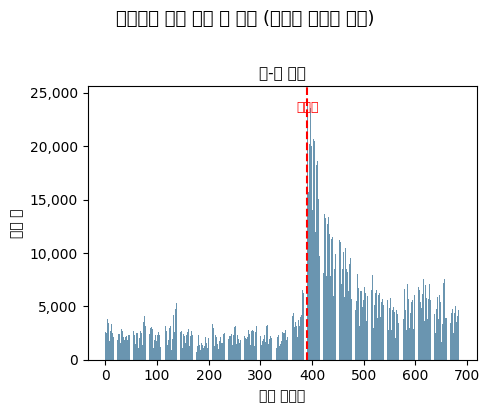

✅ 저장 완료: 01_raw_article_count.png


In [23]:
# ── 이벤트별 일별 기사 수 분포 (발발일 점선 추가) ───────────────────────────────

if all_war_data:
    n_raw = len(all_war_data)
    fig, axes = plt.subplots(1, n_raw, figsize=(5 * n_raw, 4))
    if n_raw == 1:
        axes = [axes]
    
    for ax, (event, df) in zip(axes, all_war_data.items()):
        # 1. 일별 기사 수 집계 및 정렬
        daily_cnt = df.groupby('date').size().sort_index()
        dates_list = daily_cnt.index.tolist() # 날짜 리스트 추출
        
        # 2. 바 차트 그리기
        ax.bar(range(len(daily_cnt)), daily_cnt.values,
               color=COLORS.get(event, 'steelblue'), alpha=0.8)
        
        # 3. [추가] EVENT_DATES에 설정된 날짜에 세로 점선 그리기
        event_origin_date = EVENT_DATES.get(event)
        
        if event_origin_date in dates_list:
            # 해당 날짜가 리스트의 몇 번째 인덱스인지 확인
            event_idx = dates_list.index(event_origin_date)
            
            # 세로 점선 추가 (vlines)
            ax.axvline(x=event_idx, color='red', linestyle='--', linewidth=1.5, label='발발일')
            
            # 점선 옆에 '발발일' 텍스트 추가 (선택 사항)
            ax.text(event_idx, ax.get_ylim()[1]*0.9, '발발일', color='red', 
                    fontsize=9, fontweight='bold', ha='center', va='bottom')

        # 4. 차트 꾸미기
        ax.set_title(EVENT_LABELS.get(event, event), fontsize=11)
        ax.set_xlabel('날짜 인덱스')
        ax.set_ylabel('기사 수')
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
            
    plt.suptitle('이벤트별 일별 기사 수 분포 (발발일 기준선 추가)', fontsize=13, y=1.02)
    plt.tight_layout()

    plt.savefig('01_raw_article_count.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ 저장 완료: 01_raw_article_count.png')
else:
    print("분석할 데이터(all_war_data)가 없습니다.")

In [24]:
MIN_DAILY_COUNT    = 5
TONE_OUTLIER_BOUND = 20

def has_geo_theme(themes_str):
    if pd.isna(themes_str) or themes_str == '':
        return False
    return any(tag in themes_str for tag in GEO_THEMES)

def preprocess(df, event_name):
    log = {'event': event_name, 'raw': len(df)}
    df  = df.copy()

    # ① 중복 제거
    df = df.drop_duplicates(subset=['url'])
    log['after_dedup'] = len(df)

    # ② tone 결측 제거
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity'])
    log['after_tone_na'] = len(df)

    # ③ 이상값 제거
    df = df[df['tone_score'].abs() <= TONE_OUTLIER_BOUND]
    log['after_outlier'] = len(df)

    # ④ 텍스트 결측 → 빈 문자열
    for col in ['themes']:
        df[col] = df[col].fillna('')

    # ⑤ _date 파생 컬럼
    df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])
    df['_date'] = df['event_timestamp'].dt.tz_convert(None).dt.normalize()

    # ⑥ 지정학 테마 필터
    df = df[df['themes'].apply(has_geo_theme)]
    log['after_geo_filter'] = len(df)

    # ⑦ 최소 기사 수 필터
    daily_cnt   = df.groupby('_date').size()
    valid_dates = daily_cnt[daily_cnt >= MIN_DAILY_COUNT].index
    df = df[df['_date'].isin(valid_dates)]
    log['after_min_count'] = len(df)
    log['valid_days']      = df['_date'].nunique()

    return df, log

clean_dfs = {}
logs = []
print('▶ 데이터 전처리\n')
header = (f'{"이벤트":<30} {"raw":>8} {"중복제거":>8} '
          f'{"이상값":>8} {"지정학":>8} {"최소건수":>8} {"유효일":>6}')
print(header)
print('-' * len(header))
for label, group_df in total_war_df.groupby('event_label'):
    # group_df는 해당 라벨에 속하는 데이터들만 모인 데이터프레임입니다.
    cleaned, log = preprocess(group_df, label)
    
    # 2. 결과 저장
    clean_dfs[label] = cleaned
    logs.append(log)
    
    # 3. 로그 출력 (기존 포맷 유지)
    print(f"{label:<30} "
          f"{log['raw']:>8,} {log['after_dedup']:>8,} "
          f"{log['after_outlier']:>8,} {log['after_geo_filter']:>8,} "
          f"{log['after_min_count']:>8,} {log['valid_days']:>6}")

# 결과 요약
preprocess_log_df = pd.DataFrame(logs)
print(f'\n✨ 전처리 완료: {len(clean_dfs)}개 이벤트')

▶ 데이터 전처리

이벤트                                 raw     중복제거      이상값      지정학     최소건수    유효일
----------------------------------------------------------------------------------
russia_ukraine_war             3,062,466 3,062,466 3,062,027 3,062,027 3,062,027    686

✨ 전처리 완료: 1개 이벤트


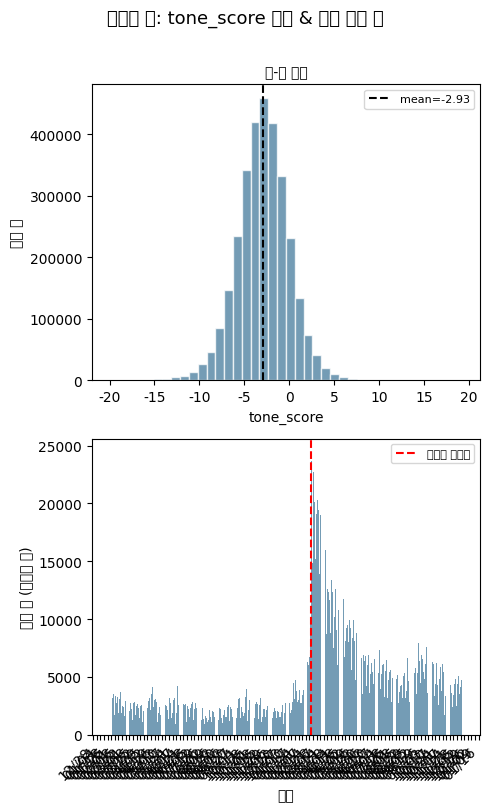

저장: 02_preprocessed_overview.png


In [25]:
if clean_dfs:
    n_ev = len(clean_dfs)
    fig, axes = plt.subplots(2, n_ev, figsize=(5 * n_ev, 8), squeeze=False)
    for col_i, (event, df) in enumerate(clean_dfs.items()):
        color = COLORS.get(event, 'steelblue')
        ax0 = axes[0, col_i]
        ax0.hist(df['tone_score'], bins=40, color=color,
                 alpha=0.75, edgecolor='white')
        ax0.axvline(df['tone_score'].mean(), color='black', lw=1.5, ls='--',
                    label=f"mean={df['tone_score'].mean():.2f}")
        ax0.set_title(EVENT_LABELS.get(event, event), fontsize=10)
        ax0.set_xlabel('tone_score')
        ax0.legend(fontsize=8)
        if col_i == 0:
            ax0.set_ylabel('기사 수')

        ax1 = axes[1, col_i]
        daily_cnt = df.groupby('_date').size()
        event_dt  = pd.Timestamp(EVENT_DATES[event])
        ax1.bar(daily_cnt.index, daily_cnt.values, color=color, alpha=0.75)
        ax1.axvline(event_dt, color='red', lw=1.5, ls='--', label='이벤트 기준일')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax1.set_xlabel('날짜')
        ax1.legend(fontsize=8)
        if col_i == 0:
            ax1.set_ylabel('기사 수 (전처리 후)')

    plt.suptitle('전처리 후: tone_score 분포 & 일별 기사 수', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('02_preprocessed_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 02_preprocessed_overview.png')

In [26]:
def compute_gpr_indices(df, event_name):
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity']).copy()

    # BUG-4 수정 완료
    df['tone_x_polarity'] = df['tone_score'] * df['polarity']

    agg = df.groupby('_date').agg(
        N                   = ('tone_score',      'count'),
        mean_tone           = ('tone_score',      'mean'),
        sum_tone_x_polarity = ('tone_x_polarity', 'sum'),
        sum_polarity        = ('polarity',         'sum'),
        mean_pos            = ('positive_score',  'mean'),
        mean_neg            = ('negative_score',  'mean'),
    ).copy()
    
    # ---------------------------------------------------------
    # [핵심] 보도량 상대적 정규화 (Relative Scaling)
    # ---------------------------------------------------------
    avg_n = agg['N'].mean()
    # 절대적 숫자 N 대신, 해당 이벤트 평균 대비 몇 배나 터졌는지(relative_N)를 사용
    agg['relative_N'] = agg['N'] / avg_n
    agg['coverage_scaled'] = np.log1p(agg['relative_N'])
    
    # F1: 단순 평균 톤 (역전)
    agg['F1_raw'] = -agg['mean_tone']

    # F2: 극성 가중 평균
    agg['F2_raw'] = np.where(
        agg['sum_polarity'] > 0,
        -agg['sum_tone_x_polarity'] / agg['sum_polarity'],
        np.nan)

    # F3: 상대적 보도량 복합 지수 (중복 계산 제거됨)
    agg['F3_raw'] = -agg['mean_tone'] * agg['coverage_scaled']

    # F4: 부정 비율
    denom = agg['mean_pos'] + agg['mean_neg']
    agg['F4_raw'] = np.where(denom > 1e-6, agg['mean_neg'] / denom, np.nan)

    # F5: F2 기반 28일 EWMA
    r, WND = 0.1, 28
    raw_w   = np.array([(1 - r) ** k for k in range(WND)])
    weights = raw_w / raw_w.sum()

    def ewma_28(series):
        result = np.full(len(series), np.nan)
        arr    = series.values
        for i in range(len(arr)):
            window = arr[max(0, i - WND + 1): i + 1][::-1]
            w_cut  = weights[:len(window)]
            w_cut  = w_cut / w_cut.sum()
            valid  = ~np.isnan(window)
            if valid.sum() > 0:
                result[i] = (np.nansum(window[valid] * w_cut[valid])
                             / w_cut[valid].sum())
        return pd.Series(result, index=series.index)

    agg = agg.sort_index()
    agg['F5_raw'] = ewma_28(agg['F2_raw'])

    # Z-score 정규화 (최종 비교용)
    for f in ['F1','F2','F3','F4','F5']:
        col = f'{f}_raw'
        mu, sig = agg[col].mean(), agg[col].std()
        agg[f'{f}_z'] = (agg[col] - mu) / sig if sig > 0 else np.nan

    agg['event_name'] = event_name
    agg['event_date'] = EVENT_DATES[event_name]
    return agg.reset_index().rename(columns={'_date': 'date'})


gpr_results = {}
print('▶ GPR 대체 지수 5종 산출\n')
print(f'{"이벤트":<30} {"유효일":>6} {"F1 mean":>9} {"F2 mean":>9} {"F3 mean":>9}')
print('-' * 70)
for event, df in clean_dfs.items():
    result = compute_gpr_indices(df, event)
    gpr_results[event] = result
    print(f"{event:<30} {len(result):>6} "
          f"{result['F1_raw'].mean():>9.3f} "
          f"{result['F2_raw'].mean():>9.3f} "
          f"{result['F3_raw'].mean():>9.3f}")
gpr_all = pd.concat(gpr_results.values(), ignore_index=True)
print(f'\n산출 완료: 총 {len(gpr_all)}행')

▶ GPR 대체 지수 5종 산출

이벤트                               유효일   F1 mean   F2 mean   F3 mean
----------------------------------------------------------------------
russia_ukraine_war                686     2.878     3.375     1.826

산출 완료: 총 686행


In [27]:
# 파일 저장 경로 설정 (1번 그룹 결과임을 명시)
output_filename = 'gpr_indices_group2.csv'

# CSV 파일로 저장
# index=False는 데이터프레임의 인덱스 번호를 저장하지 않기 위함입니다.
gpr_all.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f'✅ 저장 완료: {output_filename}')

✅ 저장 완료: gpr_indices_group2.csv


## 나머지 전쟁

In [4]:
# 1. GCS 파일 시스템 클라이언트 생성 (fs 정의)
fs = gcsfs.GCSFileSystem()

# 2. 필요한 컬럼 리스트 정의
cols_to_use = [
    'event_timestamp', 'event_date', 'url', 'tone_score', 
    'positive_score', 'negative_score', 'polarity', 'themes'
]

all_war_data = {}
war_list = ['israel_hamas_war', 'israel_iran']

# 'israel_hamas_war', 'israel_iran', 'us_israel_iran'
for war in war_list:
    # 각 버킷 내의 파일 패턴 설정 (실제 파일 이름에 따라 _ 또는 - 확인 필요)
    path = f'gs://{war}/{war}_*'  
    files = fs.glob(path)
    
    if files:
        # read_csv 시 usecols를 사용하여 필요한 컬럼만 메모리에 로드합니다.
        try:
            temp_df = pd.concat(
                [pd.read_csv(f"gs://{f}", usecols=cols_to_use) for f in files], 
                ignore_index=True
            )
            if 'event_date' in temp_df.columns:
                temp_df.rename(columns={'event_date': 'date'}, inplace=True)
            temp_df['event_label'] = war
            
            all_war_data[war] = temp_df
            print(f"✅ {war} 로드 완료: {len(temp_df)} 행")
        except Exception as e:
            print(f"❌ {war} 로드 중 오류 발생: {e}")

# 3. 모든 전쟁 데이터를 하나의 거대한 데이터프레임으로 통합
if all_war_data:
    total_war_df = pd.concat(all_war_data.values(), ignore_index=True)
    total_war_df = total_war_df.sort_values(by='event_timestamp', ascending=True).reset_index(drop=True)
    print(f"\n🚀 최종 통합 완료! 전체 행 개수: {len(total_war_df)}")
    display(total_war_df.head())
else:
    print("로드된 데이터가 없습니다.")

✅ israel_hamas_war 로드 완료: 827387 행
✅ israel_iran 로드 완료: 1863366 행

🚀 최종 통합 완료! 전체 행 개수: 2690753


,event_timestamp,date,url,tone_score,positive_score,negative_score,polarity,themes,event_label
0,2022-12-17 00:00:00 UTC,2022-12-17,https://siouxcityjournal.com/news/world/huge-b...,-2.092676,1.793722,3.886398,5.680120,"NATURAL_DISASTER_FREEZING_TEMPERATURES,1285;AR...",israel_hamas_war
1,2022-12-17 00:00:00 UTC,2022-12-17,https://menafn.com/1105319861/Intersect-Innova...,7.792208,8.051948,0.259740,8.311688,"TAX_ETHNICITY_PALESTINIAN,262;TAX_ETHNICITY_PA...",israel_hamas_war
2,2022-12-17 00:00:00 UTC,2022-12-17,https://www.irishsun.com/news/273220629/lebane...,0.000000,4.306220,4.306220,8.612440,"KILL,123;KILL,220;TAX_FNCACT_CHIEF,431;TAX_DIS...",israel_hamas_war
3,2022-12-17 00:00:00 UTC,2022-12-17,https://www.nigeriasun.com/news/273221871/un-w...,-2.545825,2.749491,5.295316,8.044807,"TAX_FNCACT_COORDINATORS,5451;MOVEMENT_WOMENS,5...",israel_hamas_war
4,2022-12-17 00:00:00 UTC,2022-12-17,https://www.irishsun.com/news/273221871/un-wee...,-2.545825,2.749491,5.295316,8.044807,"TAX_FNCACT_COORDINATORS,5451;MOVEMENT_WOMENS,5...",israel_hamas_war


In [5]:
# ── 데이터 기본 탐색 (통합 데이터용) ─────────────────────────────────────

if 'total_war_df' in locals() and not total_war_df.empty:
    print(f'▶ 통합 데이터 탐색 진행\n')
    
    print('기간:', total_war_df["date"].min(), '~', total_war_df["date"].max())
    print('전체 행수:', len(total_war_df))
    print()
    
    print('결측치 합계:')
    print(total_war_df.isnull().sum())
    
    print('\n수치형 컬럼 기술통계:')
    # 분석에 필요한 핵심 수치 컬럼들만 요약
    stats_cols = ['tone_score', 'positive_score', 'negative_score', 'polarity']
    display(total_war_df[stats_cols].describe().round(3))
else:
    print('탐색할 데이터프레임(total_war_df)이 존재하지 않습니다.')

▶ 통합 데이터 탐색 진행

기간: 2022-12-17 ~ 2025-03-15
전체 행수: 2690753

결측치 합계:
event_timestamp    0
date               0
url                0
tone_score         0
positive_score     0
negative_score     0
polarity           0
themes             0
event_label        0
dtype: int64

수치형 컬럼 기술통계:


,tone_score,positive_score,negative_score,polarity
count,2690753.000,2690753.000,2690753.000,2690753.000
mean,-4.284,2.192,6.476,8.668
std,3.091,1.219,2.481,2.393
min,-44.444,0.000,0.000,0.000
25%,-6.302,1.376,4.768,7.080
50%,-4.352,2.035,6.435,8.605
75%,-2.264,2.826,8.060,10.128
max,20.963,22.946,44.444,44.444


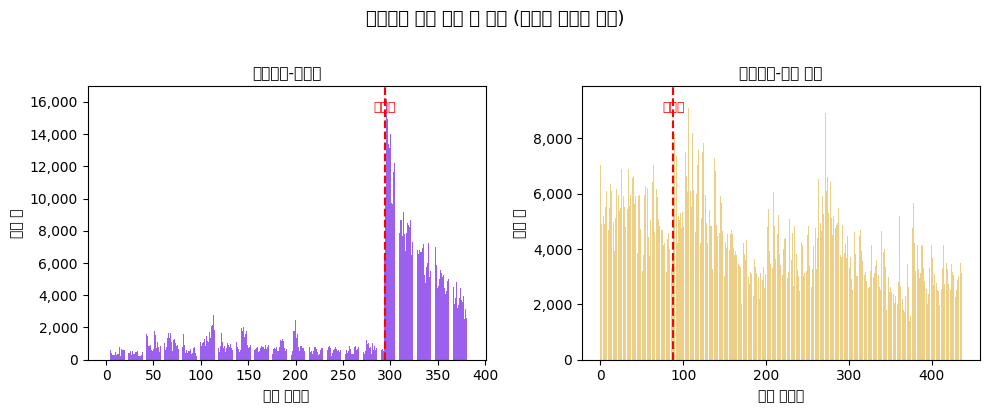

✅ 저장 완료: 01_raw_article_count.png


In [6]:
# ── 이벤트별 일별 기사 수 분포 (발발일 점선 추가) ───────────────────────────────

if all_war_data:
    n_raw = len(all_war_data)
    fig, axes = plt.subplots(1, n_raw, figsize=(5 * n_raw, 4))
    if n_raw == 1:
        axes = [axes]
    
    for ax, (event, df) in zip(axes, all_war_data.items()):
        # 1. 일별 기사 수 집계 및 정렬
        daily_cnt = df.groupby('date').size().sort_index()
        dates_list = daily_cnt.index.tolist() # 날짜 리스트 추출
        
        # 2. 바 차트 그리기
        ax.bar(range(len(daily_cnt)), daily_cnt.values,
               color=COLORS.get(event, 'steelblue'), alpha=0.8)
        
        # 3. [추가] EVENT_DATES에 설정된 날짜에 세로 점선 그리기
        event_origin_date = EVENT_DATES.get(event)
        
        if event_origin_date in dates_list:
            # 해당 날짜가 리스트의 몇 번째 인덱스인지 확인
            event_idx = dates_list.index(event_origin_date)
            
            # 세로 점선 추가 (vlines)
            ax.axvline(x=event_idx, color='red', linestyle='--', linewidth=1.5, label='발발일')
            
            # 점선 옆에 '발발일' 텍스트 추가 (선택 사항)
            ax.text(event_idx, ax.get_ylim()[1]*0.9, '발발일', color='red', 
                    fontsize=9, fontweight='bold', ha='center', va='bottom')

        # 4. 차트 꾸미기
        ax.set_title(EVENT_LABELS.get(event, event), fontsize=11)
        ax.set_xlabel('날짜 인덱스')
        ax.set_ylabel('기사 수')
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
            
    plt.suptitle('이벤트별 일별 기사 수 분포 (발발일 기준선 추가)', fontsize=13, y=1.02)
    plt.tight_layout()

    plt.savefig('01_raw_article_count.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ 저장 완료: 01_raw_article_count.png')
else:
    print("분석할 데이터(all_war_data)가 없습니다.")

In [7]:
MIN_DAILY_COUNT    = 5
TONE_OUTLIER_BOUND = 20

def has_geo_theme(themes_str):
    if pd.isna(themes_str) or themes_str == '':
        return False
    return any(tag in themes_str for tag in GEO_THEMES)

def preprocess(df, event_name):
    log = {'event': event_name, 'raw': len(df)}
    df  = df.copy()

    # ① 중복 제거
    df = df.drop_duplicates(subset=['url'])
    log['after_dedup'] = len(df)

    # ② tone 결측 제거
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity'])
    log['after_tone_na'] = len(df)

    # ③ 이상값 제거
    df = df[df['tone_score'].abs() <= TONE_OUTLIER_BOUND]
    log['after_outlier'] = len(df)

    # ④ 텍스트 결측 → 빈 문자열
    for col in ['themes']:
        df[col] = df[col].fillna('')

    # ⑤ _date 파생 컬럼
    df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])
    df['_date'] = df['event_timestamp'].dt.tz_convert(None).dt.normalize()

    # ⑥ 지정학 테마 필터
    df = df[df['themes'].apply(has_geo_theme)]
    log['after_geo_filter'] = len(df)

    # ⑦ 최소 기사 수 필터
    daily_cnt   = df.groupby('_date').size()
    valid_dates = daily_cnt[daily_cnt >= MIN_DAILY_COUNT].index
    df = df[df['_date'].isin(valid_dates)]
    log['after_min_count'] = len(df)
    log['valid_days']      = df['_date'].nunique()

    return df, log

clean_dfs = {}
logs = []
print('▶ 데이터 전처리\n')
header = (f'{"이벤트":<30} {"raw":>8} {"중복제거":>8} '
          f'{"이상값":>8} {"지정학":>8} {"최소건수":>8} {"유효일":>6}')
print(header)
print('-' * len(header))
for label, group_df in total_war_df.groupby('event_label'):
    # group_df는 해당 라벨에 속하는 데이터들만 모인 데이터프레임입니다.
    cleaned, log = preprocess(group_df, label)
    
    # 2. 결과 저장
    clean_dfs[label] = cleaned
    logs.append(log)
    
    # 3. 로그 출력 (기존 포맷 유지)
    print(f"{label:<30} "
          f"{log['raw']:>8,} {log['after_dedup']:>8,} "
          f"{log['after_outlier']:>8,} {log['after_geo_filter']:>8,} "
          f"{log['after_min_count']:>8,} {log['valid_days']:>6}")

# 결과 요약
preprocess_log_df = pd.DataFrame(logs)
print(f'\n✨ 전처리 완료: {len(clean_dfs)}개 이벤트')

▶ 데이터 전처리

이벤트                                 raw     중복제거      이상값      지정학     최소건수    유효일
----------------------------------------------------------------------------------
israel_hamas_war                827,387  827,387  827,182  827,182  827,182    382
israel_iran                    1,863,366 1,863,366 1,862,588 1,862,588 1,862,588    437

✨ 전처리 완료: 2개 이벤트


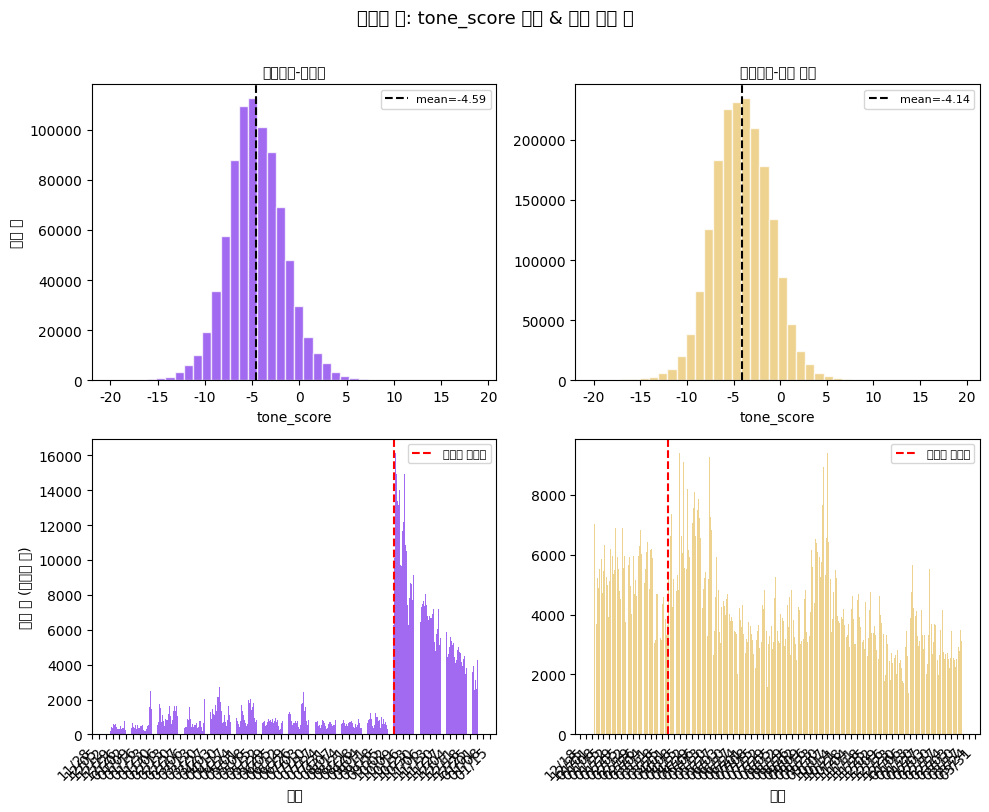

저장: 02_preprocessed_overview.png


In [8]:
if clean_dfs:
    n_ev = len(clean_dfs)
    fig, axes = plt.subplots(2, n_ev, figsize=(5 * n_ev, 8), squeeze=False)
    for col_i, (event, df) in enumerate(clean_dfs.items()):
        color = COLORS.get(event, 'steelblue')
        ax0 = axes[0, col_i]
        ax0.hist(df['tone_score'], bins=40, color=color,
                 alpha=0.75, edgecolor='white')
        ax0.axvline(df['tone_score'].mean(), color='black', lw=1.5, ls='--',
                    label=f"mean={df['tone_score'].mean():.2f}")
        ax0.set_title(EVENT_LABELS.get(event, event), fontsize=10)
        ax0.set_xlabel('tone_score')
        ax0.legend(fontsize=8)
        if col_i == 0:
            ax0.set_ylabel('기사 수')

        ax1 = axes[1, col_i]
        daily_cnt = df.groupby('_date').size()
        event_dt  = pd.Timestamp(EVENT_DATES[event])
        ax1.bar(daily_cnt.index, daily_cnt.values, color=color, alpha=0.75)
        ax1.axvline(event_dt, color='red', lw=1.5, ls='--', label='이벤트 기준일')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax1.set_xlabel('날짜')
        ax1.legend(fontsize=8)
        if col_i == 0:
            ax1.set_ylabel('기사 수 (전처리 후)')

    plt.suptitle('전처리 후: tone_score 분포 & 일별 기사 수', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('02_preprocessed_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 02_preprocessed_overview.png')

In [9]:
def compute_gpr_indices(df, event_name):
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity']).copy()

    # BUG-4 수정 완료
    df['tone_x_polarity'] = df['tone_score'] * df['polarity']

    agg = df.groupby('_date').agg(
        N                   = ('tone_score',      'count'),
        mean_tone           = ('tone_score',      'mean'),
        sum_tone_x_polarity = ('tone_x_polarity', 'sum'),
        sum_polarity        = ('polarity',         'sum'),
        mean_pos            = ('positive_score',  'mean'),
        mean_neg            = ('negative_score',  'mean'),
    ).copy()
    
    # ---------------------------------------------------------
    # [핵심] 보도량 상대적 정규화 (Relative Scaling)
    # ---------------------------------------------------------
    avg_n = agg['N'].mean()
    # 절대적 숫자 N 대신, 해당 이벤트 평균 대비 몇 배나 터졌는지(relative_N)를 사용
    agg['relative_N'] = agg['N'] / avg_n
    agg['coverage_scaled'] = np.log1p(agg['relative_N'])
    
    # F1: 단순 평균 톤 (역전)
    agg['F1_raw'] = -agg['mean_tone']

    # F2: 극성 가중 평균
    agg['F2_raw'] = np.where(
        agg['sum_polarity'] > 0,
        -agg['sum_tone_x_polarity'] / agg['sum_polarity'],
        np.nan)

    # F3: 상대적 보도량 복합 지수 (중복 계산 제거됨)
    agg['F3_raw'] = -agg['mean_tone'] * agg['coverage_scaled']

    # F4: 부정 비율
    denom = agg['mean_pos'] + agg['mean_neg']
    agg['F4_raw'] = np.where(denom > 1e-6, agg['mean_neg'] / denom, np.nan)

    # F5: F2 기반 28일 EWMA
    r, WND = 0.1, 28
    raw_w   = np.array([(1 - r) ** k for k in range(WND)])
    weights = raw_w / raw_w.sum()

    def ewma_28(series):
        result = np.full(len(series), np.nan)
        arr    = series.values
        for i in range(len(arr)):
            window = arr[max(0, i - WND + 1): i + 1][::-1]
            w_cut  = weights[:len(window)]
            w_cut  = w_cut / w_cut.sum()
            valid  = ~np.isnan(window)
            if valid.sum() > 0:
                result[i] = (np.nansum(window[valid] * w_cut[valid])
                             / w_cut[valid].sum())
        return pd.Series(result, index=series.index)

    agg = agg.sort_index()
    agg['F5_raw'] = ewma_28(agg['F2_raw'])

    # Z-score 정규화 (최종 비교용)
    for f in ['F1','F2','F3','F4','F5']:
        col = f'{f}_raw'
        mu, sig = agg[col].mean(), agg[col].std()
        agg[f'{f}_z'] = (agg[col] - mu) / sig if sig > 0 else np.nan

    agg['event_name'] = event_name
    agg['event_date'] = EVENT_DATES[event_name]
    return agg.reset_index().rename(columns={'_date': 'date'})


gpr_results = {}
print('▶ GPR 대체 지수 5종 산출\n')
print(f'{"이벤트":<30} {"유효일":>6} {"F1 mean":>9} {"F2 mean":>9} {"F3 mean":>9}')
print('-' * 70)
for event, df in clean_dfs.items():
    result = compute_gpr_indices(df, event)
    gpr_results[event] = result
    print(f"{event:<30} {len(result):>6} "
          f"{result['F1_raw'].mean():>9.3f} "
          f"{result['F2_raw'].mean():>9.3f} "
          f"{result['F3_raw'].mean():>9.3f}")
gpr_all = pd.concat(gpr_results.values(), ignore_index=True)
print(f'\n산출 완료: 총 {len(gpr_all)}행')

▶ GPR 대체 지수 5종 산출

이벤트                               유효일   F1 mean   F2 mean   F3 mean
----------------------------------------------------------------------
israel_hamas_war                  382     3.960     4.560     2.441
israel_iran                       437     4.132     4.648     2.804

산출 완료: 총 819행


In [10]:
# 파일 저장 경로 설정 (1번 그룹 결과임을 명시)
output_filename = 'gpr_indices_group3.csv'

# CSV 파일로 저장
# index=False는 데이터프레임의 인덱스 번호를 저장하지 않기 위함입니다.
gpr_all.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f'✅ 저장 완료: {output_filename}')

✅ 저장 완료: gpr_indices_group3.csv


## 미-이란-이스라엘

In [ ]:
# 1. GCS 파일 시스템 클라이언트 생성 (fs 정의)
fs = gcsfs.GCSFileSystem()

# 2. 필요한 컬럼 리스트 정의
cols_to_use = [
    'event_timestamp', 'event_date', 'url', 'tone_score', 
    'positive_score', 'negative_score', 'polarity', 'themes'
]

all_war_data = {}
war_list = ['us_israel_iran']

# 'israel_hamas_war', 'israel_iran', 'us_israel_iran'
for war in war_list:
    # 각 버킷 내의 파일 패턴 설정 (실제 파일 이름에 따라 _ 또는 - 확인 필요)
    path = f'gs://{war}/{war}_*'  
    files = fs.glob(path)
    
    if files:
        # read_csv 시 usecols를 사용하여 필요한 컬럼만 메모리에 로드합니다.
        try:
            temp_df = pd.concat(
                [pd.read_csv(f"gs://{f}", usecols=cols_to_use) for f in files], 
                ignore_index=True
            )
            if 'event_date' in temp_df.columns:
                temp_df.rename(columns={'event_date': 'date'}, inplace=True)
            temp_df['event_label'] = war
            
            all_war_data[war] = temp_df
            print(f"✅ {war} 로드 완료: {len(temp_df)} 행")
        except Exception as e:
            print(f"❌ {war} 로드 중 오류 발생: {e}")

# 3. 모든 전쟁 데이터를 하나의 거대한 데이터프레임으로 통합
if all_war_data:
    total_war_df = pd.concat(all_war_data.values(), ignore_index=True)
    total_war_df = total_war_df.sort_values(by='event_timestamp', ascending=True).reset_index(drop=True)
    print(f"\n🚀 최종 통합 완료! 전체 행 개수: {len(total_war_df)}")
    display(total_war_df.head())
else:
    print("로드된 데이터가 없습니다.")

In [ ]:
# ── 데이터 기본 탐색 (통합 데이터용) ─────────────────────────────────────

if 'total_war_df' in locals() and not total_war_df.empty:
    print(f'▶ 통합 데이터 탐색 진행\n')
    
    print('기간:', total_war_df["date"].min(), '~', total_war_df["date"].max())
    print('전체 행수:', len(total_war_df))
    print()
    
    print('결측치 합계:')
    print(total_war_df.isnull().sum())
    
    print('\n수치형 컬럼 기술통계:')
    # 분석에 필요한 핵심 수치 컬럼들만 요약
    stats_cols = ['tone_score', 'positive_score', 'negative_score', 'polarity']
    display(total_war_df[stats_cols].describe().round(3))
else:
    print('탐색할 데이터프레임(total_war_df)이 존재하지 않습니다.')

In [ ]:
# ── 이벤트별 일별 기사 수 분포 (발발일 점선 추가) ───────────────────────────────

if all_war_data:
    n_raw = len(all_war_data)
    fig, axes = plt.subplots(1, n_raw, figsize=(5 * n_raw, 4))
    if n_raw == 1:
        axes = [axes]
    
    for ax, (event, df) in zip(axes, all_war_data.items()):
        # 1. 일별 기사 수 집계 및 정렬
        daily_cnt = df.groupby('date').size().sort_index()
        dates_list = daily_cnt.index.tolist() # 날짜 리스트 추출
        
        # 2. 바 차트 그리기
        ax.bar(range(len(daily_cnt)), daily_cnt.values,
               color=COLORS.get(event, 'steelblue'), alpha=0.8)
        
        # 3. [추가] EVENT_DATES에 설정된 날짜에 세로 점선 그리기
        event_origin_date = EVENT_DATES.get(event)
        
        if event_origin_date in dates_list:
            # 해당 날짜가 리스트의 몇 번째 인덱스인지 확인
            event_idx = dates_list.index(event_origin_date)
            
            # 세로 점선 추가 (vlines)
            ax.axvline(x=event_idx, color='red', linestyle='--', linewidth=1.5, label='발발일')
            
            # 점선 옆에 '발발일' 텍스트 추가 (선택 사항)
            ax.text(event_idx, ax.get_ylim()[1]*0.9, '발발일', color='red', 
                    fontsize=9, fontweight='bold', ha='center', va='bottom')

        # 4. 차트 꾸미기
        ax.set_title(EVENT_LABELS.get(event, event), fontsize=11)
        ax.set_xlabel('날짜 인덱스')
        ax.set_ylabel('기사 수')
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
            
    plt.suptitle('이벤트별 일별 기사 수 분포 (발발일 기준선 추가)', fontsize=13, y=1.02)
    plt.tight_layout()

    plt.savefig('01_raw_article_count.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ 저장 완료: 01_raw_article_count.png')
else:
    print("분석할 데이터(all_war_data)가 없습니다.")

In [ ]:
MIN_DAILY_COUNT    = 5
TONE_OUTLIER_BOUND = 20

def has_geo_theme(themes_str):
    if pd.isna(themes_str) or themes_str == '':
        return False
    return any(tag in themes_str for tag in GEO_THEMES)

def preprocess(df, event_name):
    log = {'event': event_name, 'raw': len(df)}
    df  = df.copy()

    # ① 중복 제거
    df = df.drop_duplicates(subset=['url'])
    log['after_dedup'] = len(df)

    # ② tone 결측 제거
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity'])
    log['after_tone_na'] = len(df)

    # ③ 이상값 제거
    df = df[df['tone_score'].abs() <= TONE_OUTLIER_BOUND]
    log['after_outlier'] = len(df)

    # ④ 텍스트 결측 → 빈 문자열
    for col in ['themes']:
        df[col] = df[col].fillna('')

    # ⑤ _date 파생 컬럼
    df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])
    df['_date'] = df['event_timestamp'].dt.tz_convert(None).dt.normalize()

    # ⑥ 지정학 테마 필터
    df = df[df['themes'].apply(has_geo_theme)]
    log['after_geo_filter'] = len(df)

    # ⑦ 최소 기사 수 필터
    daily_cnt   = df.groupby('_date').size()
    valid_dates = daily_cnt[daily_cnt >= MIN_DAILY_COUNT].index
    df = df[df['_date'].isin(valid_dates)]
    log['after_min_count'] = len(df)
    log['valid_days']      = df['_date'].nunique()

    return df, log

clean_dfs = {}
logs = []
print('▶ 데이터 전처리\n')
header = (f'{"이벤트":<30} {"raw":>8} {"중복제거":>8} '
          f'{"이상값":>8} {"지정학":>8} {"최소건수":>8} {"유효일":>6}')
print(header)
print('-' * len(header))
for label, group_df in total_war_df.groupby('event_label'):
    # group_df는 해당 라벨에 속하는 데이터들만 모인 데이터프레임입니다.
    cleaned, log = preprocess(group_df, label)
    
    # 2. 결과 저장
    clean_dfs[label] = cleaned
    logs.append(log)
    
    # 3. 로그 출력 (기존 포맷 유지)
    print(f"{label:<30} "
          f"{log['raw']:>8,} {log['after_dedup']:>8,} "
          f"{log['after_outlier']:>8,} {log['after_geo_filter']:>8,} "
          f"{log['after_min_count']:>8,} {log['valid_days']:>6}")

# 결과 요약
preprocess_log_df = pd.DataFrame(logs)
print(f'\n✨ 전처리 완료: {len(clean_dfs)}개 이벤트')

In [ ]:
if clean_dfs:
    n_ev = len(clean_dfs)
    fig, axes = plt.subplots(2, n_ev, figsize=(5 * n_ev, 8), squeeze=False)
    for col_i, (event, df) in enumerate(clean_dfs.items()):
        color = COLORS.get(event, 'steelblue')
        ax0 = axes[0, col_i]
        ax0.hist(df['tone_score'], bins=40, color=color,
                 alpha=0.75, edgecolor='white')
        ax0.axvline(df['tone_score'].mean(), color='black', lw=1.5, ls='--',
                    label=f"mean={df['tone_score'].mean():.2f}")
        ax0.set_title(EVENT_LABELS.get(event, event), fontsize=10)
        ax0.set_xlabel('tone_score')
        ax0.legend(fontsize=8)
        if col_i == 0:
            ax0.set_ylabel('기사 수')

        ax1 = axes[1, col_i]
        daily_cnt = df.groupby('_date').size()
        event_dt  = pd.Timestamp(EVENT_DATES[event])
        ax1.bar(daily_cnt.index, daily_cnt.values, color=color, alpha=0.75)
        ax1.axvline(event_dt, color='red', lw=1.5, ls='--', label='이벤트 기준일')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax1.set_xlabel('날짜')
        ax1.legend(fontsize=8)
        if col_i == 0:
            ax1.set_ylabel('기사 수 (전처리 후)')

    plt.suptitle('전처리 후: tone_score 분포 & 일별 기사 수', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('02_preprocessed_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 02_preprocessed_overview.png')

In [ ]:
def compute_gpr_indices(df, event_name):
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity']).copy()

    # BUG-4 수정 완료
    df['tone_x_polarity'] = df['tone_score'] * df['polarity']

    agg = df.groupby('_date').agg(
        N                   = ('tone_score',      'count'),
        mean_tone           = ('tone_score',      'mean'),
        sum_tone_x_polarity = ('tone_x_polarity', 'sum'),
        sum_polarity        = ('polarity',         'sum'),
        mean_pos            = ('positive_score',  'mean'),
        mean_neg            = ('negative_score',  'mean'),
    ).copy()
    
    # ---------------------------------------------------------
    # [핵심] 보도량 상대적 정규화 (Relative Scaling)
    # ---------------------------------------------------------
    avg_n = agg['N'].mean()
    # 절대적 숫자 N 대신, 해당 이벤트 평균 대비 몇 배나 터졌는지(relative_N)를 사용
    agg['relative_N'] = agg['N'] / avg_n
    agg['coverage_scaled'] = np.log1p(agg['relative_N'])
    
    # F1: 단순 평균 톤 (역전)
    agg['F1_raw'] = -agg['mean_tone']

    # F2: 극성 가중 평균
    agg['F2_raw'] = np.where(
        agg['sum_polarity'] > 0,
        -agg['sum_tone_x_polarity'] / agg['sum_polarity'],
        np.nan)

    # F3: 상대적 보도량 복합 지수 (중복 계산 제거됨)
    agg['F3_raw'] = -agg['mean_tone'] * agg['coverage_scaled']

    # F4: 부정 비율
    denom = agg['mean_pos'] + agg['mean_neg']
    agg['F4_raw'] = np.where(denom > 1e-6, agg['mean_neg'] / denom, np.nan)

    # F5: F2 기반 28일 EWMA
    r, WND = 0.1, 28
    raw_w   = np.array([(1 - r) ** k for k in range(WND)])
    weights = raw_w / raw_w.sum()

    def ewma_28(series):
        result = np.full(len(series), np.nan)
        arr    = series.values
        for i in range(len(arr)):
            window = arr[max(0, i - WND + 1): i + 1][::-1]
            w_cut  = weights[:len(window)]
            w_cut  = w_cut / w_cut.sum()
            valid  = ~np.isnan(window)
            if valid.sum() > 0:
                result[i] = (np.nansum(window[valid] * w_cut[valid])
                             / w_cut[valid].sum())
        return pd.Series(result, index=series.index)

    agg = agg.sort_index()
    agg['F5_raw'] = ewma_28(agg['F2_raw'])

    # Z-score 정규화 (최종 비교용)
    for f in ['F1','F2','F3','F4','F5']:
        col = f'{f}_raw'
        mu, sig = agg[col].mean(), agg[col].std()
        agg[f'{f}_z'] = (agg[col] - mu) / sig if sig > 0 else np.nan

    agg['event_name'] = event_name
    agg['event_date'] = EVENT_DATES[event_name]
    return agg.reset_index().rename(columns={'_date': 'date'})


gpr_results = {}
print('▶ GPR 대체 지수 5종 산출\n')
print(f'{"이벤트":<30} {"유효일":>6} {"F1 mean":>9} {"F2 mean":>9} {"F3 mean":>9}')
print('-' * 70)
for event, df in clean_dfs.items():
    result = compute_gpr_indices(df, event)
    gpr_results[event] = result
    print(f"{event:<30} {len(result):>6} "
          f"{result['F1_raw'].mean():>9.3f} "
          f"{result['F2_raw'].mean():>9.3f} "
          f"{result['F3_raw'].mean():>9.3f}")
gpr_all = pd.concat(gpr_results.values(), ignore_index=True)
print(f'\n산출 완료: 총 {len(gpr_all)}행')

In [ ]:
# 파일 저장 경로 설정 (1번 그룹 결과임을 명시)
output_filename = 'gpr_indices_group4.csv'

# CSV 파일로 저장
# index=False는 데이터프레임의 인덱스 번호를 저장하지 않기 위함입니다.
gpr_all.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f'✅ 저장 완료: {output_filename}')

## 파일 통합

In [5]:
import pandas as pd

# 1. 파일 리스트 정의 (가지고 계신 파일명과 일치하는지 확인하세요)
file_list = [
    'gpr_indices_group1.csv', 
    'gpr_indices_group2.csv', 
    'gpr_indices_group3.csv',
    'gpr_indices_group4.csv'
]

combined_list = []

print("📂 파일 로드 및 통합 시작...")

for file in file_list:
    try:
        # 파일 읽기
        df = pd.read_csv(file)
        combined_list.append(df)
        print(f"✅ {file} 로드 완료: {len(df):,} 행")
    except FileNotFoundError:
        print(f"❌ {file}을 찾을 수 없습니다. 파일명을 확인해 주세요.")

# 2. 데이터 통합 (Concat)
if combined_list:
    total_custom_gpr = pd.concat(combined_list, ignore_index=True)
    
    # 3. 날짜 형식 변환 및 정렬
    # 컬럼명이 'date'인지 '_date'인지 확인 후 맞춰주세요 (여기선 'date' 기준)
    date_col = 'date' if 'date' in total_custom_gpr.columns else '_date'
    
    total_custom_gpr[date_col] = pd.to_datetime(total_custom_gpr[date_col])
    
    # 이벤트별로 묶고 그 안에서 날짜순으로 정렬
    total_custom_gpr = total_custom_gpr.sort_values(by=['event_name', date_col]).reset_index(drop=True)
    
    # 4. 최종 통합 파일 저장
    output_name = 'total_custom_gpr_final.csv'
    total_custom_gpr.to_csv(output_name, index=False, encoding='utf-8-sig')
    
    print(f"\n🚀 최종 통합 완료!")
    print(f"📍 파일 저장 위치: {output_name}")
    print(f"📍 전체 데이터 행수: {len(total_custom_gpr):,}")
    
    # 결과 확인
    display(total_custom_gpr.head())
else:
    print("⚠️ 통합할 데이터가 없습니다.")

📂 파일 로드 및 통합 시작...
✅ gpr_indices_group1.csv 로드 완료: 757 행
✅ gpr_indices_group2.csv 로드 완료: 686 행
✅ gpr_indices_group3.csv 로드 완료: 819 행
✅ gpr_indices_group4.csv 로드 완료: 393 행

🚀 최종 통합 완료!
📍 파일 저장 위치: total_custom_gpr_final.csv
📍 전체 데이터 행수: 2,655


,date,N,mean_tone,sum_tone_x_polarity,sum_polarity,mean_pos,mean_neg,relative_N,coverage_scaled,F1_raw,...,F3_raw,F4_raw,F5_raw,F1_z,F2_z,F3_z,F4_z,F5_z,event_name,event_date
0,2019-01-01,364,-2.553468,-7398.410016,2656.407599,2.372178,4.925645,0.276824,0.244375,2.553468,...,0.624005,0.674947,2.785119,-1.267362,-1.375349,-0.986062,-1.333809,-3.295405,hormuz_crisis,2019-06-13
1,2019-01-02,420,-3.508872,-12417.685125,3146.357991,1.991228,5.500100,0.319412,0.277186,3.508872,...,0.972610,0.734196,3.396470,0.064986,0.138445,-0.773613,0.129983,-1.333957,hormuz_crisis,2019-06-13
2,2019-01-03,1160,-4.939393,-56527.656418,10488.934628,2.051396,6.990789,0.882185,0.632433,4.939393,...,3.123837,0.773131,4.131819,2.059905,2.018466,0.537399,1.091912,1.025325,hormuz_crisis,2019-06-13
3,2019-01-04,609,-2.934362,-14362.653018,4325.409318,2.084058,5.018420,0.463147,0.380590,2.934362,...,1.116788,0.706573,3.895910,-0.736190,-0.677582,-0.685748,-0.552459,0.268441,hormuz_crisis,2019-06-13
4,2019-01-05,394,-2.666511,-7815.197018,2697.765769,2.090305,4.756816,0.299639,0.262086,2.666511,...,0.698856,0.694718,3.651961,-1.109718,-1.229652,-0.940446,-0.845359,-0.514241,hormuz_crisis,2019-06-13


# 이후 진행 동일

---
## Step 4. 공식 GPR 로드

- 원본: 월별 | 변환: 일별 forward fill | 정규화: Z-score
> 다운로드: https://www.matteoiacoviello.com/gpr.htm → `data_gpr_daily_recent.xls`


- GPR 엑셀 파일 접근 오류 때문에, 일단 Custom만 진행

In [5]:
!pip install --upgrade pandas

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl (9.7 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3


  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
def load_official_gpr(path):
    if not os.path.exists(path):
        print(f'⚠️  {path} 없음 → 공식 GPR 없이 진행 (F1 기준 내부 상관분석)')
        return None
    try:
        gpr_raw = pd.read_csv(path)
    except Exception:
        try:
            gpr_raw = pd.read_stata(path)
        except Exception as e:
            print(f'GPR 파일 로드 실패: {e}')
            return None

    print('컬럼 목록:', list(gpr_raw.columns))
    print(gpr_raw.head(3))

    date_col = 'date' if 'date' in gpr_raw.columns else 'DAY'
    gpr_col = 'GPRD' if 'GPRD' in gpr_raw.columns else 'GPR'


    if date_col is None or gpr_col is None:
        print(f'컬럼 탐지 실패 — date_col={date_col}, gpr_col={gpr_col}')
        print("수동 지정: date_col='<날짜컬럼>', gpr_col='<GPR컬럼>'")
        return None

    print(f'\n날짜 컬럼: {date_col}, GPR 컬럼: {gpr_col}')
    gpr_raw[gpr_col] = pd.to_numeric(gpr_raw[gpr_col], errors='coerce')
    
    # 4. 날짜 변환 및 정리
    gpr_raw[date_col] = pd.to_datetime(gpr_raw[date_col].astype(str), errors='coerce')
    monthly = (
        gpr_raw[[date_col, gpr_col]].dropna()
        .rename(columns={date_col: 'month', gpr_col: 'GPR'})
        .set_index('month').sort_index()
    )
    daily_idx = pd.date_range(
        monthly.index.min(),
        monthly.index.max() + pd.offsets.MonthEnd(0),
        freq='D')
    daily = monthly.reindex(daily_idx).ffill()
    daily.index.name = 'date'
    daily['GPR_zscore'] = (
        (daily['GPR'] - daily['GPR'].mean()) / daily['GPR'].std())
    print(f'\n공식 GPR: {daily.index.min().date()} ~ {daily.index.max().date()}')
    return daily

gpr_daily = load_official_gpr(GPR_FILE)

컬럼 목록: ['DAY', 'N10D', 'GPRD', 'GPRD_ACT', 'GPRD_THREAT', 'date', 'GPRD_MA30', 'GPRD_MA7', 'event', 'var_name', 'var_label']
        DAY  N10D    GPRD GPRD_ACT  GPRD_THREAT        date  GPRD_MA30  \
0  19850101   216  230.04   275.20       153.03  1985-01-01     230.04   
1  19850102   315  115.68   146.77        87.44  1985-01-02     172.86   
2  19850103   374   97.43   158.94        29.46  1985-01-03     147.71   

   GPRD_MA7 event var_name                                         var_label  
0    230.04   NaN      DAY                                               DAY  
1    172.86   NaN     N10D  Number of articles (10 recent newspapers, 1985-)  
2    147.71   NaN     GPRD                  Daily GPR (Index: 1985:2019=100)  

날짜 컬럼: date, GPR 컬럼: GPRD

공식 GPR: 1985-01-01 ~ 2026-05-31


---
## Step 6. 공식 GPR과 상관관계 분석

- **Pearson r**: 선형 관계 강도
- **Spearman r**: 순위 기반 비선형 관계
- **p-value**: < 0.05 = 통계적 유의
- 공식 GPR 없을 경우 F1~F5 내부 상관분석으로 대체

In [17]:
CUSTOM_GPR_FILE = 'total_custom_gpr_final.csv'
result_df = pd.read_csv(CUSTOM_GPR_FILE)

display(result_df.head())

,date,N,mean_tone,sum_tone_x_polarity,sum_polarity,mean_pos,mean_neg,relative_N,coverage_scaled,F1_raw,...,F3_raw,F4_raw,F5_raw,F1_z,F2_z,F3_z,F4_z,F5_z,event_name,event_date
0,2019-01-01,364,-2.553468,-7398.410016,2656.407599,2.372178,4.925645,0.276824,0.244375,2.553468,...,0.624005,0.674947,2.785119,-1.267362,-1.375349,-0.986062,-1.333809,-3.295405,hormuz_crisis,2019-06-13
1,2019-01-02,420,-3.508872,-12417.685125,3146.357991,1.991228,5.500100,0.319412,0.277186,3.508872,...,0.972610,0.734196,3.396470,0.064986,0.138445,-0.773613,0.129983,-1.333957,hormuz_crisis,2019-06-13
2,2019-01-03,1160,-4.939393,-56527.656418,10488.934628,2.051396,6.990789,0.882185,0.632433,4.939393,...,3.123837,0.773131,4.131819,2.059905,2.018466,0.537399,1.091912,1.025325,hormuz_crisis,2019-06-13
3,2019-01-04,609,-2.934362,-14362.653018,4325.409318,2.084058,5.018420,0.463147,0.380590,2.934362,...,1.116788,0.706573,3.895910,-0.736190,-0.677582,-0.685748,-0.552459,0.268441,hormuz_crisis,2019-06-13
4,2019-01-05,394,-2.666511,-7815.197018,2697.765769,2.090305,4.756816,0.299639,0.262086,2.666511,...,0.698856,0.694718,3.651961,-1.109718,-1.229652,-0.940446,-0.845359,-0.514241,hormuz_crisis,2019-06-13


In [24]:
!pip uninstall pandas -y
!pip install pandas==2.2.3

Found existing installation: pandas 3.0.2
Uninstalling pandas-3.0.2:
  Successfully uninstalled pandas-3.0.2
  Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl (11.5 MB)



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:

def merge_with_official_gpr(result_df, gpr_daily_df):
    if gpr_daily_df is None:
        return result_df
    gpr_ref = gpr_daily_df[['GPR','GPR_zscore']].copy()
    gpr_ref.index = pd.to_datetime(gpr_ref.index)
    result_df = result_df.copy()
    result_df['date'] = pd.to_datetime(result_df['date'])
    result_df = result_df.set_index('date').join(gpr_ref, how='left')
    return result_df.reset_index()


def correlation_analysis(result_df, event_name, gpr_available):
    # BUG-5 수정: ref_series 변수 선언 후 미사용 → 제거하고 로직 단순화
    rows           = []
    formula_cols_z = ['F1_z','F2_z','F3_z','F4_z','F5_z']

    if gpr_available and 'GPR_zscore' in result_df.columns:
        ref_label    = 'GPR 공식 (Z-score)'
        target_col   = 'GPR_zscore'
        compare_cols = formula_cols_z
    else:
        ref_label    = 'F1_z (기준)'
        target_col   = 'F1_z'
        compare_cols = formula_cols_z[1:]  # F2~F5 vs F1

    for f_col in compare_cols:
        pair = result_df[[f_col, target_col]].dropna()
        if len(pair) < 5:
            rows.append({'formula': f_col, 'n': len(pair),
                         'pearson_r': np.nan, 'pearson_p': np.nan,
                         'spearman_r': np.nan, 'spearman_p': np.nan})
            continue
        pr, pp = stats.pearsonr(pair[f_col], pair[target_col])
        sr, sp = stats.spearmanr(pair[f_col], pair[target_col])
        rows.append({'formula': f_col, 'n': len(pair),
                     'pearson_r': pr, 'pearson_p': pp,
                     'spearman_r': sr, 'spearman_p': sp})

    corr_df = pd.DataFrame(rows)
    corr_df['event']    = event_name
    corr_df['ref']      = ref_label
    corr_df['sig_5pct'] = corr_df['pearson_p'].apply(
        lambda p: '✅' if (pd.notna(p) and p < 0.05) else '—')
    return corr_df

gpr_results = {label: group for label, group in result_df.groupby('event_name')}

gpr_available  = gpr_daily is not None
merged_results = {}
for event, result in gpr_results.items():
    merged_results[event] = merge_with_official_gpr(result, gpr_daily)

all_corr = []
print(f'▶ 상관관계 분석 ({"공식 GPR 기준" if gpr_available else "F1 기준"})\n')
for event, result in merged_results.items():
    corr_df = correlation_analysis(result, event, gpr_available)
    all_corr.append(corr_df)
    print(f'  [{EVENT_LABELS.get(event, event)}]')
    print(corr_df[['formula','n','pearson_r','pearson_p',
                    'spearman_r','spearman_p','sig_5pct']].to_string(index=False))
    print()

# BUG-6 수정: all_corr가 비어있으면 pd.concat → ValueError
#   → 빈 경우 빈 DataFrame으로 안전 처리
corr_summary = pd.concat(all_corr, ignore_index=True) if all_corr else pd.DataFrame()

▶ 상관관계 분석 (공식 GPR 기준)

  [호르무즈 위기]
formula   n  pearson_r    pearson_p  spearman_r   spearman_p sig_5pct
   F1_z 265   0.043836 4.773532e-01    0.053245 3.879841e-01        —
   F2_z 265   0.023810 6.996319e-01    0.033812 5.837090e-01        —
   F3_z 265   0.335393 2.181693e-08    0.302168 5.348780e-07        ✅
   F4_z 265   0.058913 3.394119e-01    0.039815 5.187128e-01        —
   F5_z 265   0.096576 1.167908e-01    0.117678 5.571526e-02        —

  [이스라엘-하마스]
formula   n  pearson_r    pearson_p  spearman_r   spearman_p sig_5pct
   F1_z 382   0.199948 8.321811e-05    0.230193 5.480082e-06        ✅
   F2_z 382   0.149588 3.383124e-03    0.198052 9.743888e-05        ✅
   F3_z 382   0.569876 2.824247e-34    0.451448 1.401278e-20        ✅
   F4_z 382   0.204799 5.519507e-05    0.220953 1.310608e-05        ✅
   F5_z 382   0.325440 7.120209e-11    0.342007 6.382321e-12        ✅

  [이스라엘-이란 충돌]
formula   n  pearson_r  pearson_p  spearman_r   spearman_p sig_5pct
   F1_z 437  -0.059441   0.

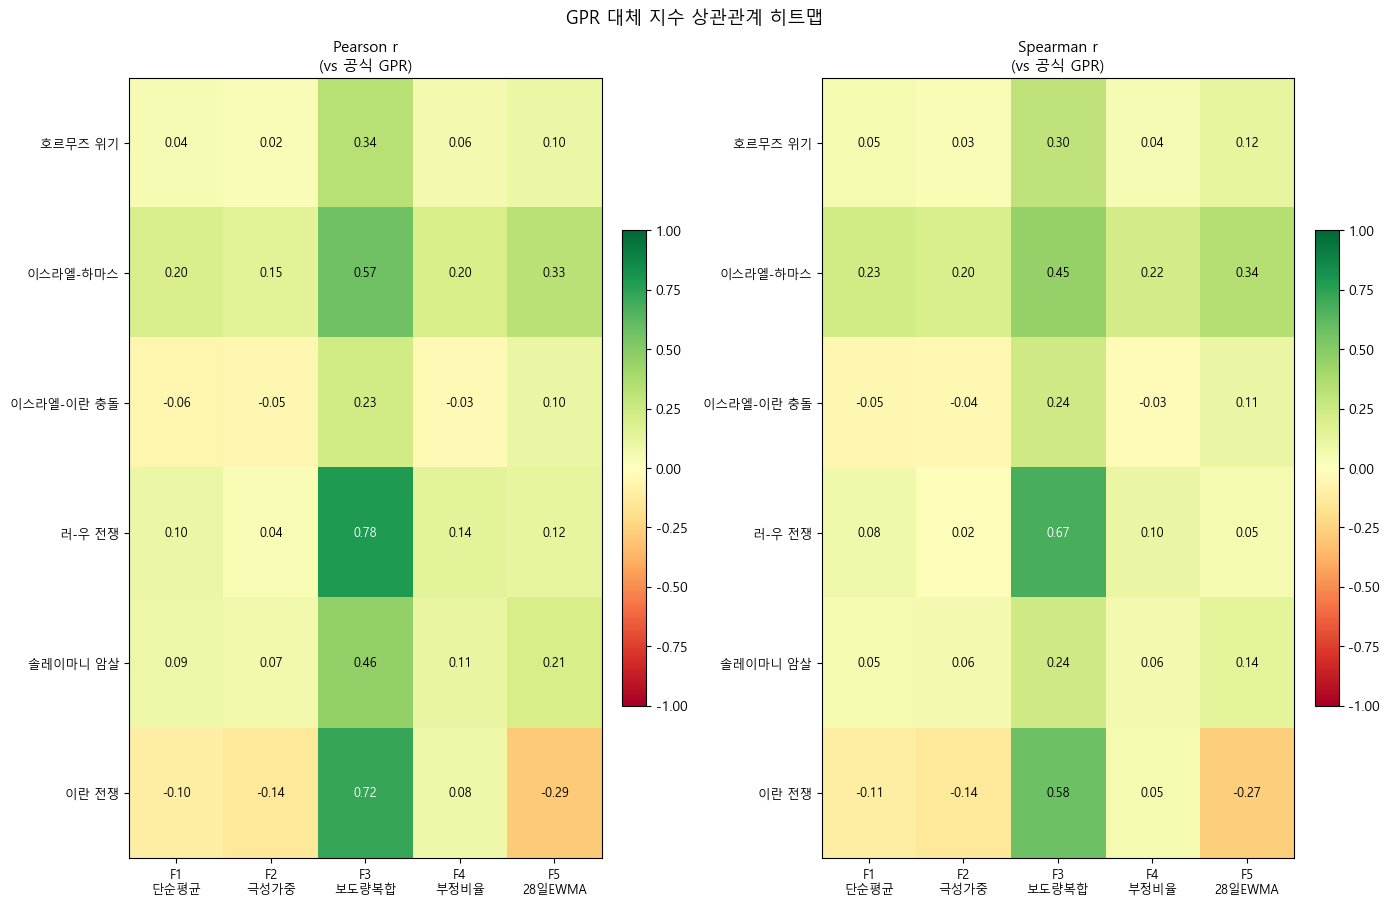

저장: 03_correlation_heatmap.png


In [25]:
# ── 상관계수 히트맵 ───────────────────────────────────────
formula_cols_z = ['F1_z','F2_z','F3_z','F4_z','F5_z']
formula_labels = ['F1\n단순평균','F2\n극성가중','F3\n보도량복합',
                  'F4\n부정비율','F5\n28일EWMA']

if corr_summary.empty:
    print('상관관계 데이터 없음 — 히트맵 생략')
else:
    fig, axes = plt.subplots(1, 2,
                             figsize=(14, max(4, len(gpr_results) * 1.2 + 2)))
    for ax_i, (metric, metric_label) in enumerate(
            [('pearson_r','Pearson r'), ('spearman_r','Spearman r')]):
        ax = axes[ax_i]
        pivot = corr_summary.pivot_table(
            index='event', columns='formula', values=metric, aggfunc='first')
        pivot = pivot.reindex(
            columns=[c for c in formula_cols_z if c in pivot.columns])
        im = ax.imshow(pivot.values.astype(float), cmap='RdYlGn',
                       vmin=-1, vmax=1, aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(pivot.shape[1]))
        ax.set_xticklabels(
            [formula_labels[formula_cols_z.index(c)]
             for c in pivot.columns], fontsize=9)
        ax.set_yticks(range(pivot.shape[0]))
        ax.set_yticklabels(
            [EVENT_LABELS.get(e, e) for e in pivot.index], fontsize=9)
        ax.set_title(
            f'{metric_label}\n({"vs 공식 GPR" if gpr_available else "vs F1"})',
            fontsize=11)
        for row in range(pivot.shape[0]):
            for col in range(pivot.shape[1]):
                val = pivot.values[row, col]
                if pd.notna(val):
                    ax.text(col, row, f'{val:.2f}', ha='center', va='center',
                            fontsize=9,
                            color='white' if abs(val) > 0.6 else 'black')
    plt.suptitle('GPR 대체 지수 상관관계 히트맵', fontsize=13)
    plt.tight_layout()
    plt.savefig('03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 03_correlation_heatmap.png')

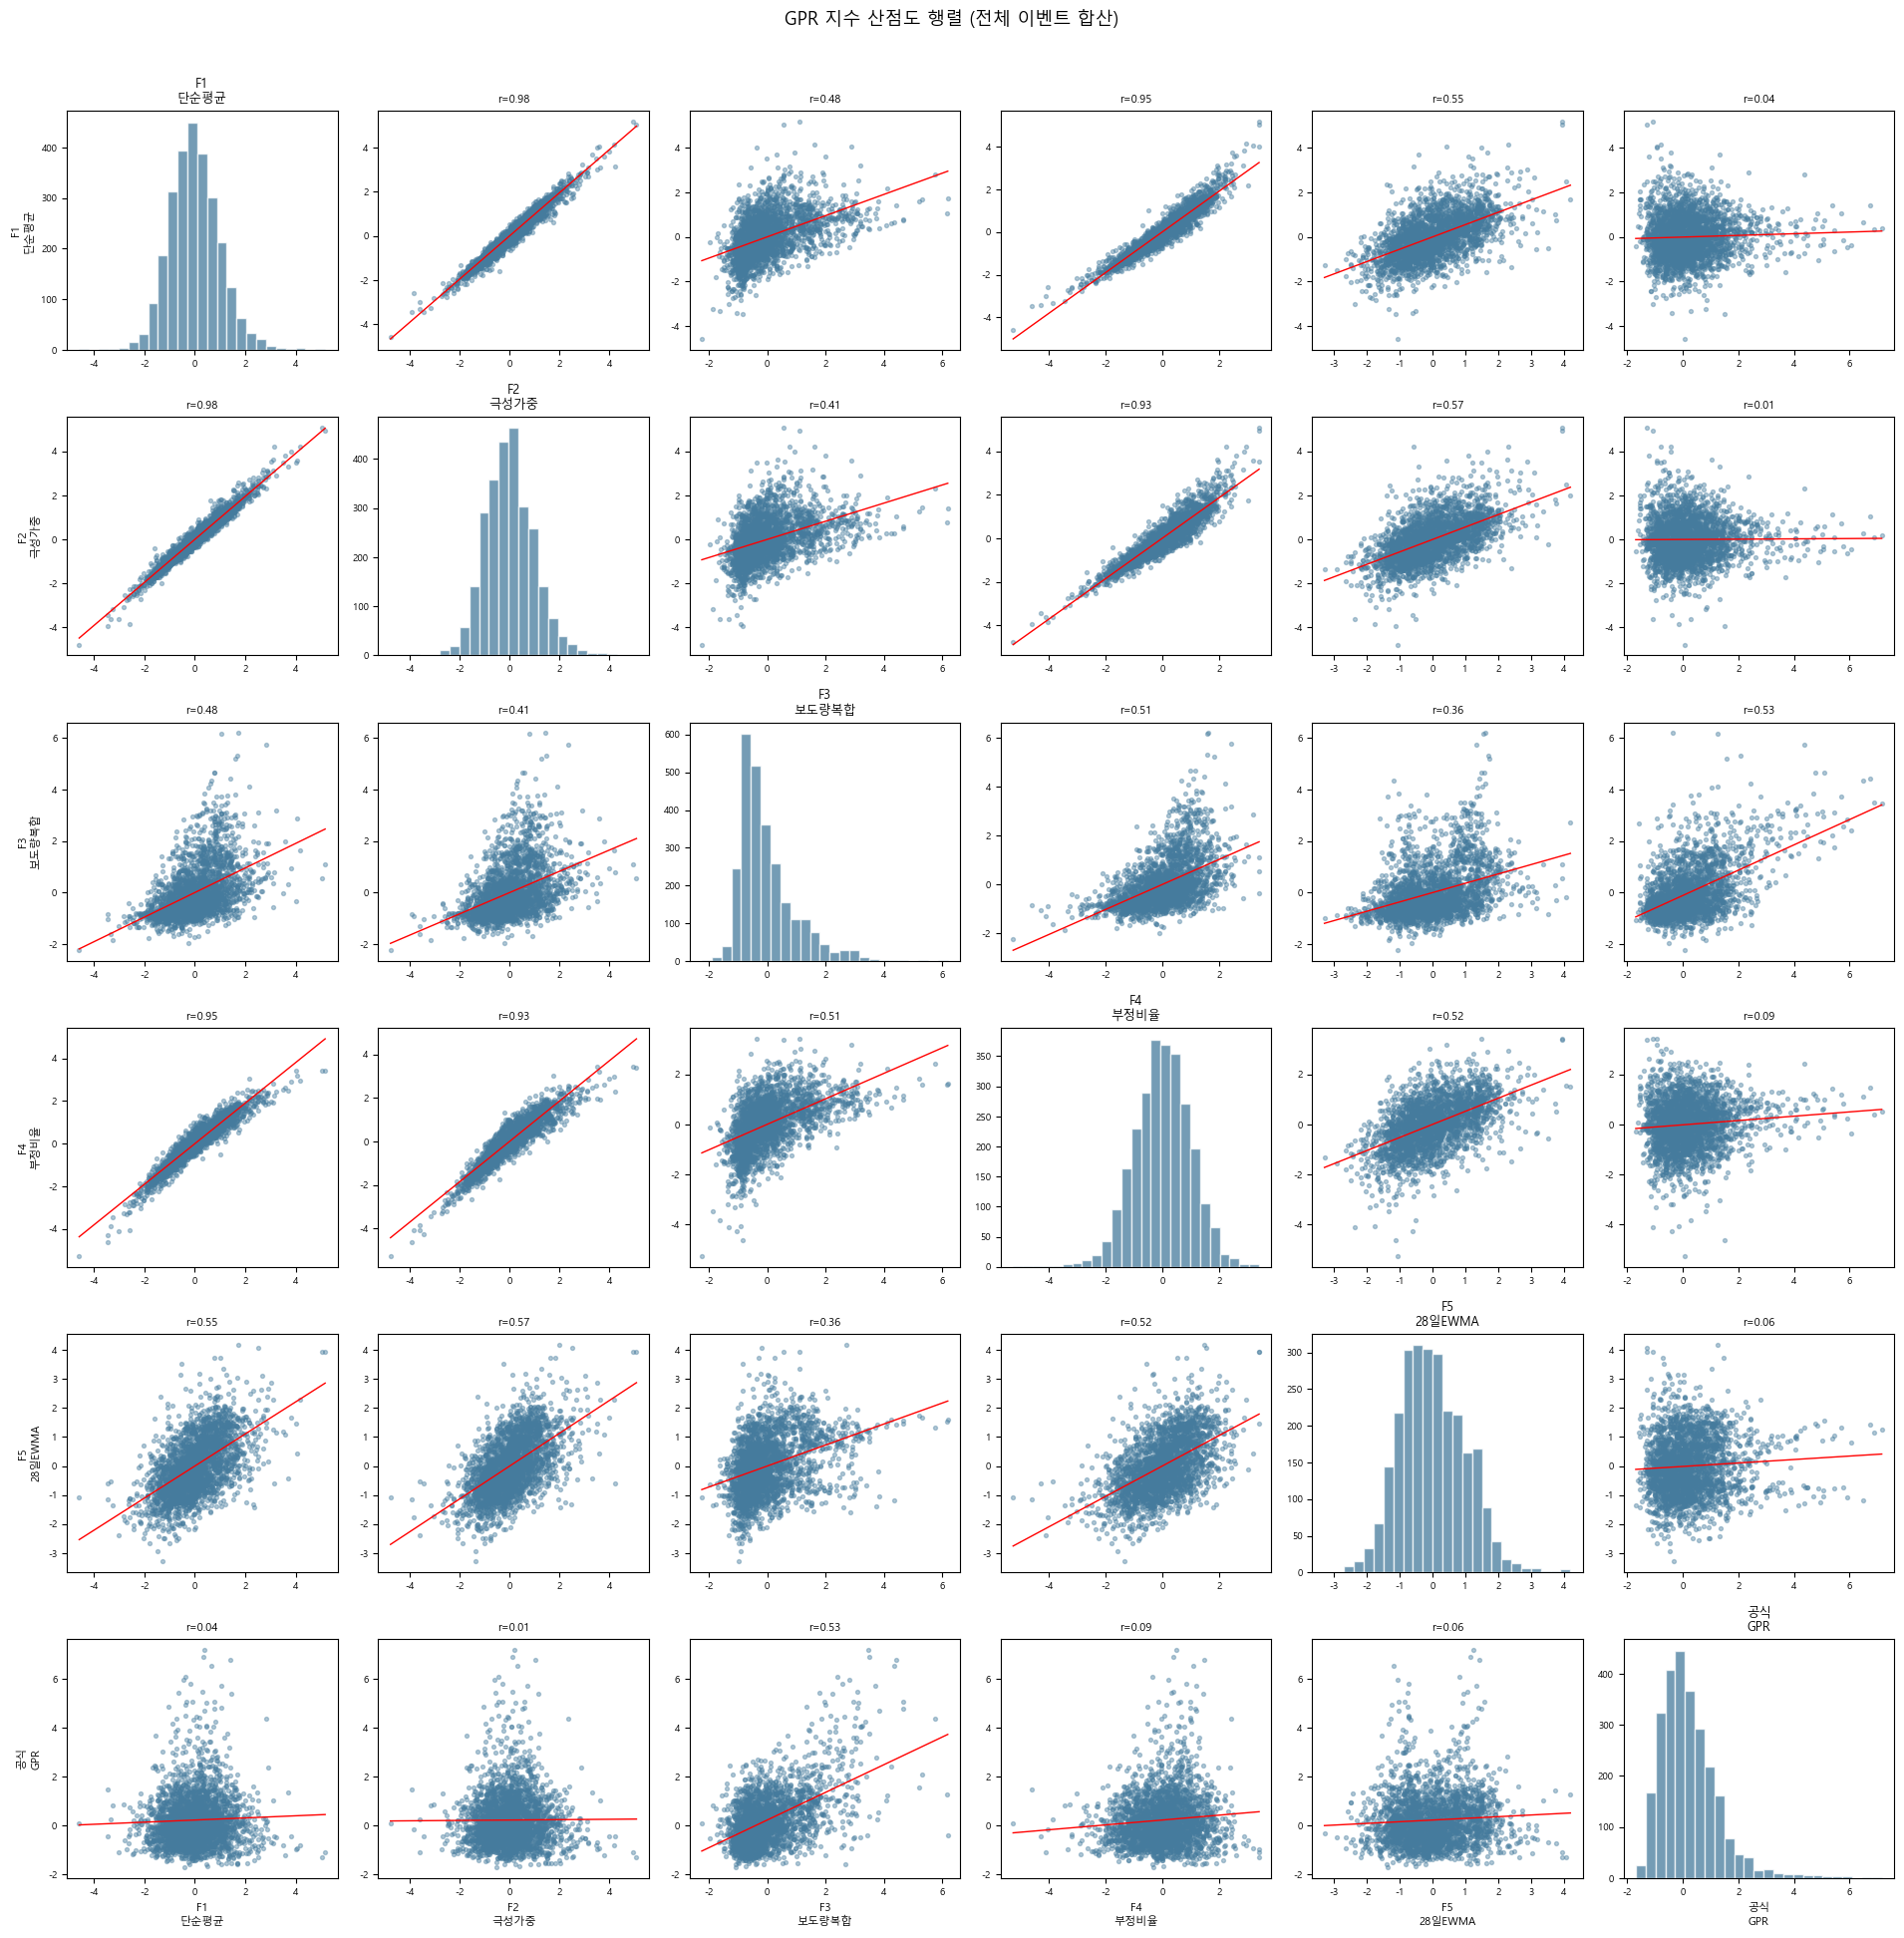

저장: 04_scatter_matrix.png


In [26]:
# ── F1~F5 산점도 행렬 ────────────────────────────────────
z_cols     = ['F1_z','F2_z','F3_z','F4_z','F5_z']
all_merged = pd.concat(merged_results.values(), ignore_index=True)

if gpr_available and 'GPR_zscore' in all_merged.columns:
    scatter_cols   = z_cols + ['GPR_zscore']
    scatter_labels = formula_labels + ['공식\nGPR']
else:
    scatter_cols   = z_cols
    scatter_labels = formula_labels

n_sc = len(scatter_cols)
fig, axes = plt.subplots(n_sc, n_sc, figsize=(3.2 * n_sc, 3.2 * n_sc))
for i, (ci, li) in enumerate(zip(scatter_cols, scatter_labels)):
    for j, (cj, lj) in enumerate(zip(scatter_cols, scatter_labels)):
        ax = axes[i, j]
        if i == j:
            data = all_merged[ci].dropna()
            ax.hist(data, bins=25, color='#457B9D', alpha=0.75, edgecolor='white')
            ax.set_title(li, fontsize=9)
        else:
            xy = all_merged[[ci, cj]].dropna()
            if len(xy) > 2:
                ax.scatter(xy[cj], xy[ci], s=8, alpha=0.4, color='#457B9D')
                m, b = np.polyfit(xy[cj], xy[ci], 1)
                xr = np.linspace(xy[cj].min(), xy[cj].max(), 50)
                ax.plot(xr, m * xr + b, 'r-', lw=1)
                r, _ = stats.pearsonr(xy[ci], xy[cj])
                ax.set_title(f'r={r:.2f}', fontsize=8)
        if i == n_sc - 1: ax.set_xlabel(lj, fontsize=8)
        if j == 0:        ax.set_ylabel(li, fontsize=8)
        ax.tick_params(labelsize=7)
plt.suptitle('GPR 지수 산점도 행렬 (전체 이벤트 합산)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('04_scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 04_scatter_matrix.png')

---
## Step 7. 시각화

### 7-1. 이벤트별 F1~F5 시계열

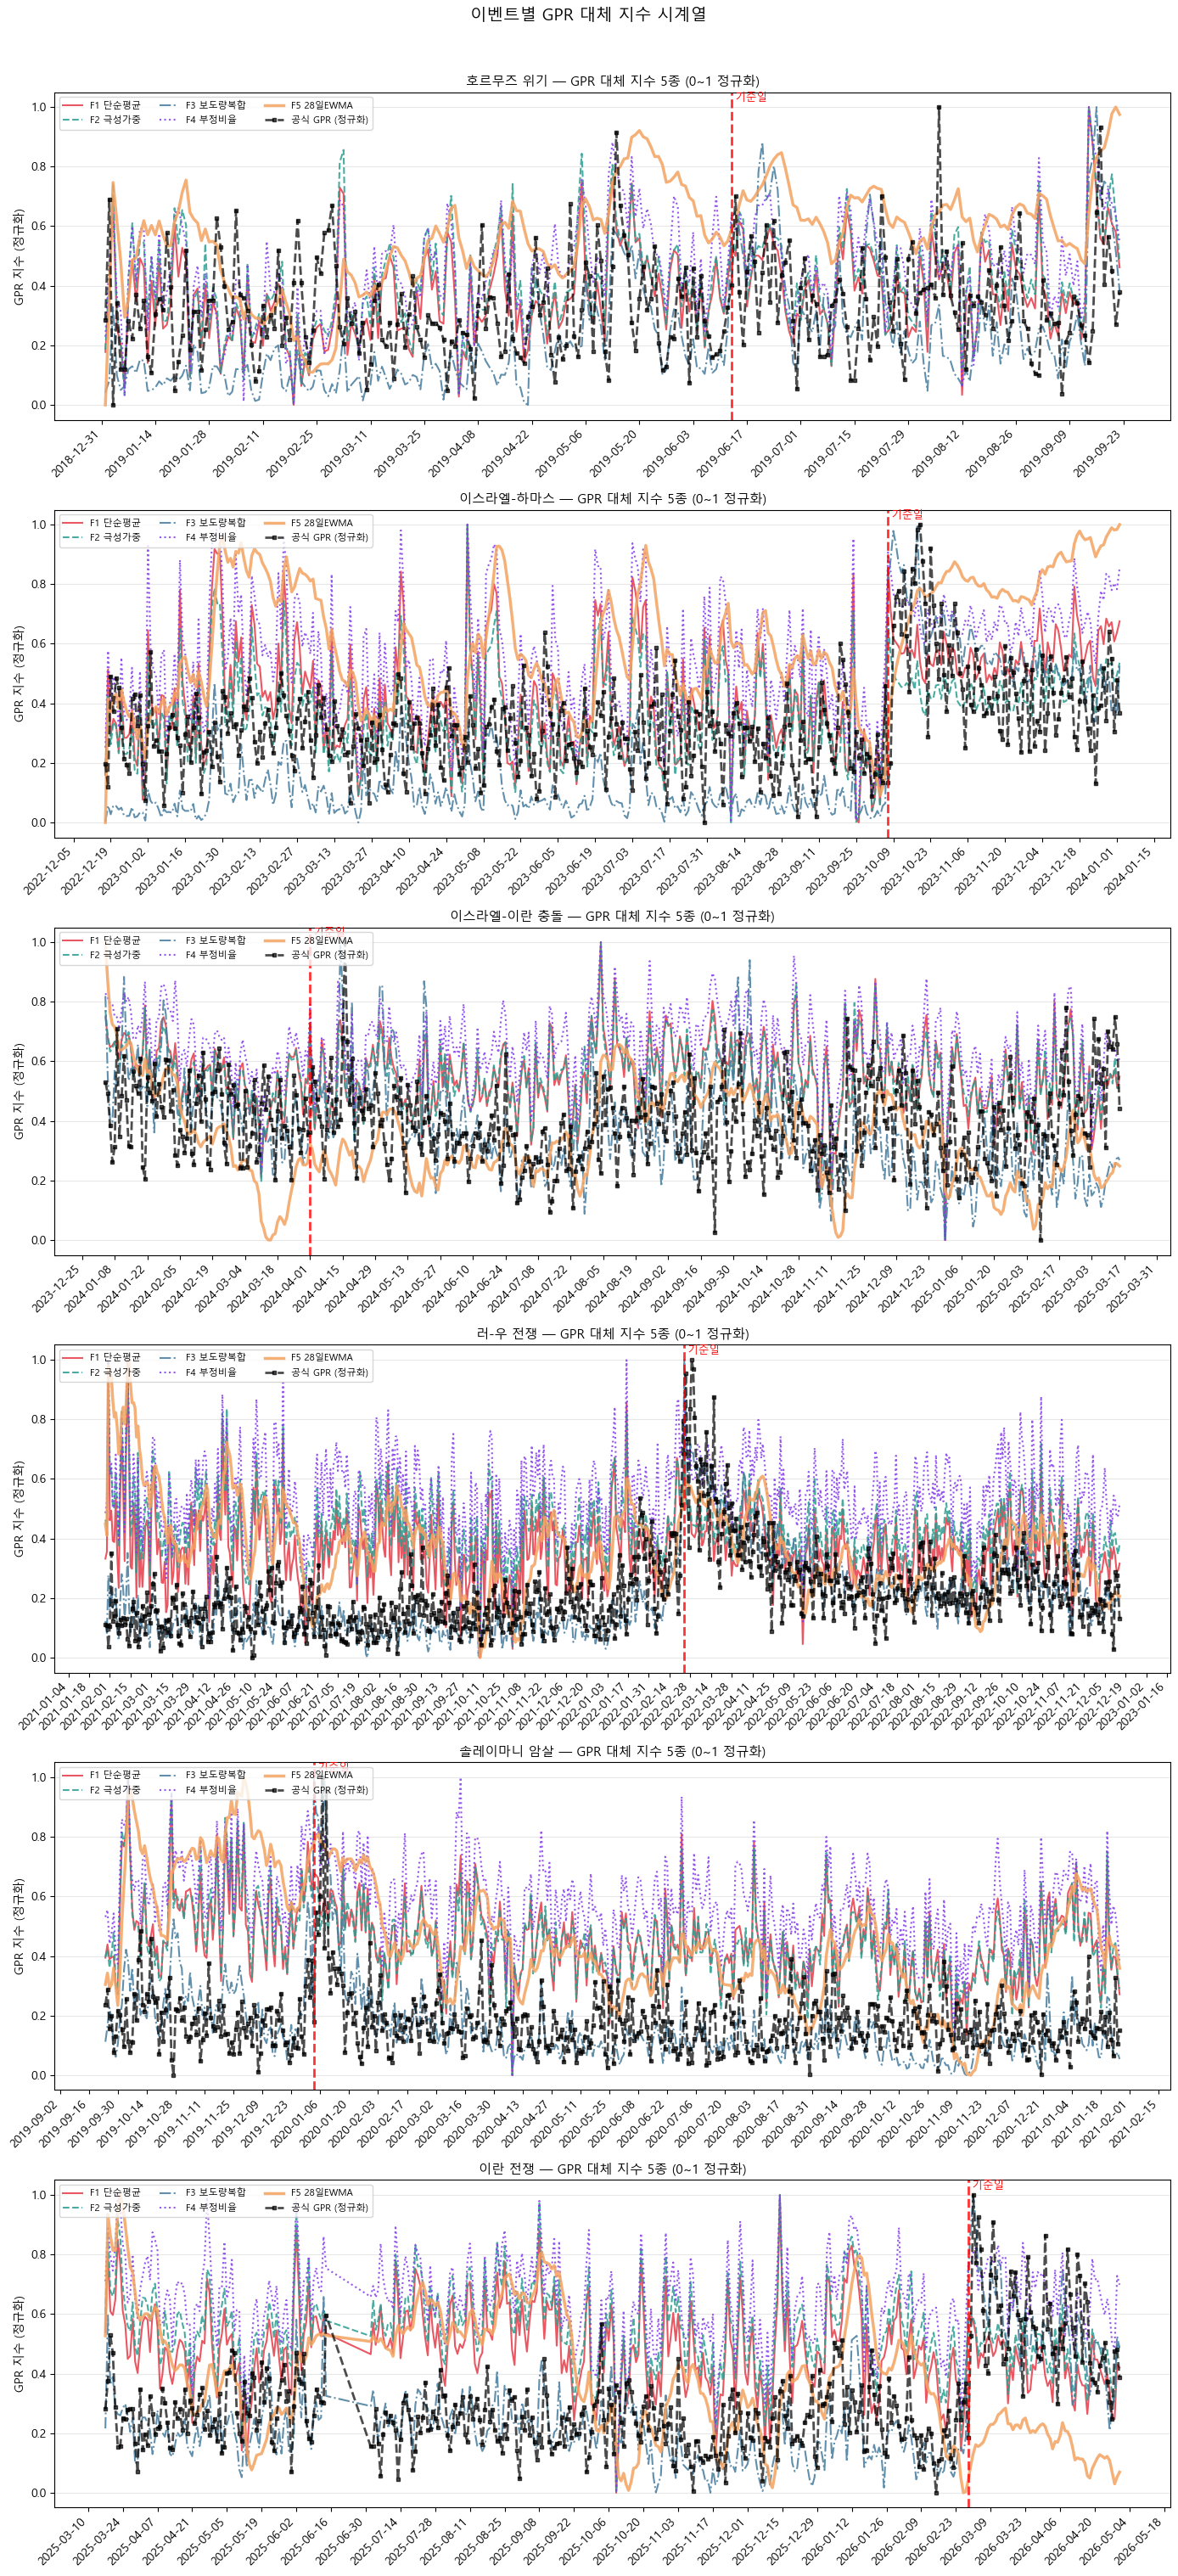

저장: 05_gpr_timeseries.png


In [27]:
raw_cols   = ['F1_raw','F2_raw','F3_raw','F4_raw','F5_raw']
raw_styles = [('-','#E63946'),('--','#2A9D8F'),('-.','#457B9D'),
              (':','#8338EC'),('-','#F4A261')]
raw_widths = [1.5, 1.5, 1.5, 1.5, 2.5]
raw_labels = ['F1 단순평균','F2 극성가중','F3 보도량복합',
              'F4 부정비율','F5 28일EWMA']

n_events = len(merged_results)
fig, axes = plt.subplots(n_events, 1, figsize=(14, 5 * n_events), sharex=False)
if n_events == 1:
    axes = [axes]

for ax, (event, result) in zip(axes, merged_results.items()):
    result   = result.copy()
    result['date'] = pd.to_datetime(result['date'])
    result   = result.sort_values('date')
    event_dt = pd.Timestamp(EVENT_DATES[event])

    for col in raw_cols:
        mn, mx = result[col].min(), result[col].max()
        result[col + '_norm'] = (
            (result[col] - mn) / (mx - mn) if mx > mn else 0.5)

    for (ls, clr), lw, lbl, col in zip(raw_styles, raw_widths, raw_labels, raw_cols):
        ax.plot(result['date'], result[col + '_norm'],
                ls=ls, color=clr, lw=lw, label=lbl, alpha=0.85)

    if gpr_available and 'GPR_zscore' in result.columns:
        gpr_sub = result[['date','GPR_zscore']].dropna()
        if len(gpr_sub) > 0:
            mn, mx  = gpr_sub['GPR_zscore'].min(), gpr_sub['GPR_zscore'].max()
            gpr_norm = (
                (gpr_sub['GPR_zscore'] - mn) / (mx - mn) if mx > mn else 0.5)
            ax.plot(gpr_sub['date'], gpr_norm, 's--', color='black',
                    lw=2, ms=3, label='공식 GPR (정규화)', alpha=0.7)

    ax.axvline(event_dt, color='red', lw=2, ls='--', alpha=0.8)
    # BUG-7 수정: axvline 직후 ax.get_ylim()[1] 호출 시 아직 ylim=(0,1) 기본값
    #   → get_xaxis_transform()으로 axes 좌표계 기준 상단 고정
    ax.text(event_dt, 1.0, ' 기준일', color='red', fontsize=9,
            va='top', transform=ax.get_xaxis_transform())

    ax.set_title(
        f'{EVENT_LABELS.get(event, event)} — GPR 대체 지수 5종 (0~1 정규화)',
        fontsize=11)
    ax.set_ylabel('GPR 지수 (정규화)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(fontsize=8, loc='upper left', ncol=3)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('이벤트별 GPR 대체 지수 시계열', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('05_gpr_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 05_gpr_timeseries.png')

### 7-2. 공식 GPR vs 우리 지수 직접 비교 (공식 GPR 있을 때)

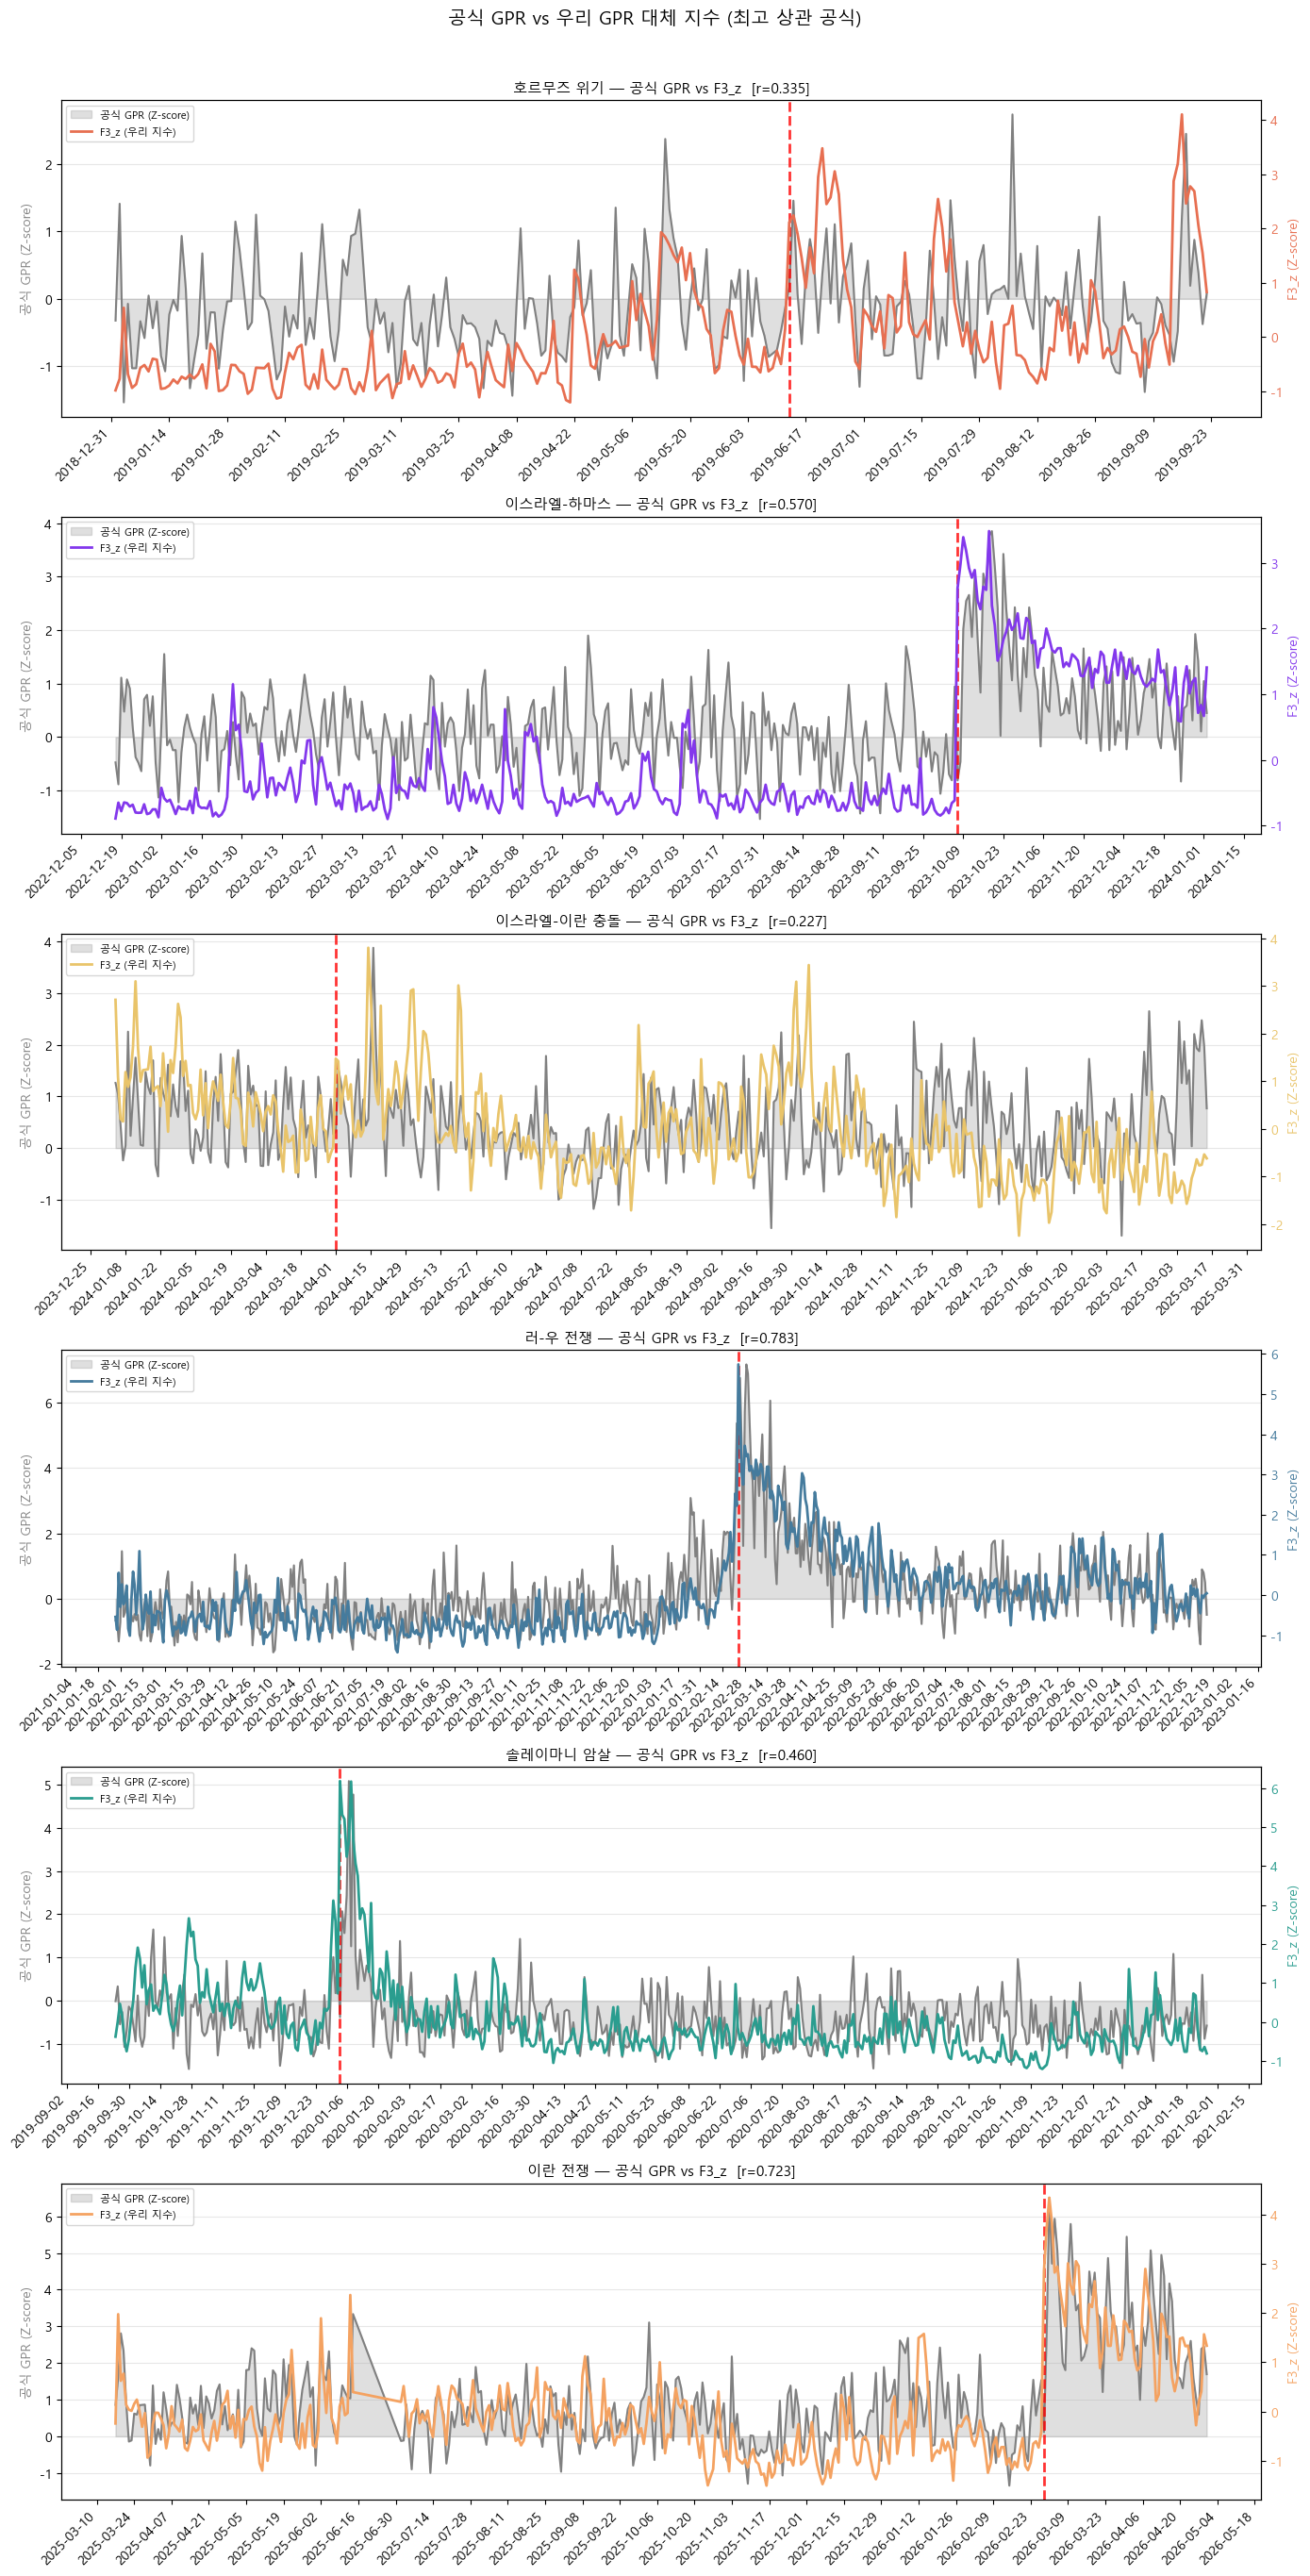

저장: 06_official_vs_ours.png


In [28]:
# BUG-8 수정: 원본 코드에서 if 블록 내 plt.show() 직후에 else:가
#   같은 셀 소스 문자열 안에서 이어졌으나 개행 처리 오류로 분리됨
#   → IndentationError. 정상적인 if/else 블록으로 재작성
if gpr_available:
    n_events = len(merged_results)
    fig, axes = plt.subplots(n_events, 1, figsize=(14, 4.5 * n_events))
    if n_events == 1:
        axes = [axes]

    best_formula = (
        corr_summary
        .loc[corr_summary.groupby('event')['pearson_r'].idxmax()]
        .set_index('event')['formula']
        if not corr_summary.empty else pd.Series(dtype=str)
    )

    for ax, (event, result) in zip(axes, merged_results.items()):
        result   = result.copy()
        result['date'] = pd.to_datetime(result['date'])
        result   = result.sort_values('date')
        event_dt = pd.Timestamp(EVENT_DATES[event])
        color    = COLORS.get(event, 'steelblue')
        best     = best_formula.get(event, 'F2_z')

        ax2 = ax.twinx()
        gpr_sub = result[['date','GPR_zscore']].dropna()
        ax.fill_between(gpr_sub['date'], gpr_sub['GPR_zscore'],
                        alpha=0.25, color='gray', label='공식 GPR (Z-score)')
        ax.plot(gpr_sub['date'], gpr_sub['GPR_zscore'], color='gray', lw=1.5)
        ax.set_ylabel('공식 GPR (Z-score)', color='gray')

        our_sub = result[['date', best]].dropna()
        ax2.plot(our_sub['date'], our_sub[best],
                 color=color, lw=2, label=f'{best} (우리 지수)')
        ax2.set_ylabel(f'{best} (Z-score)', color=color)
        ax2.tick_params(axis='y', labelcolor=color)

        r_row = corr_summary.loc[
            (corr_summary['event'] == event) &
            (corr_summary['formula'] == best), 'pearson_r']
        r_str = f'r={r_row.values[0]:.3f}' if len(r_row) > 0 else ''
        ax.set_title(
            f'{EVENT_LABELS.get(event, event)} — 공식 GPR vs {best}  [{r_str}]',
            fontsize=11)

        ax.axvline(event_dt, color='red', lw=2, ls='--', alpha=0.8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2,
                  fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('공식 GPR vs 우리 GPR 대체 지수 (최고 상관 공식)',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('06_official_vs_ours.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 06_official_vs_ours.png')
else:
    print('공식 GPR 파일 없음 → 이 셀은 건너뜁니다.')

### 7-3. 이벤트 전후 ±26일 GPR 변화 (이벤트 스터디형)

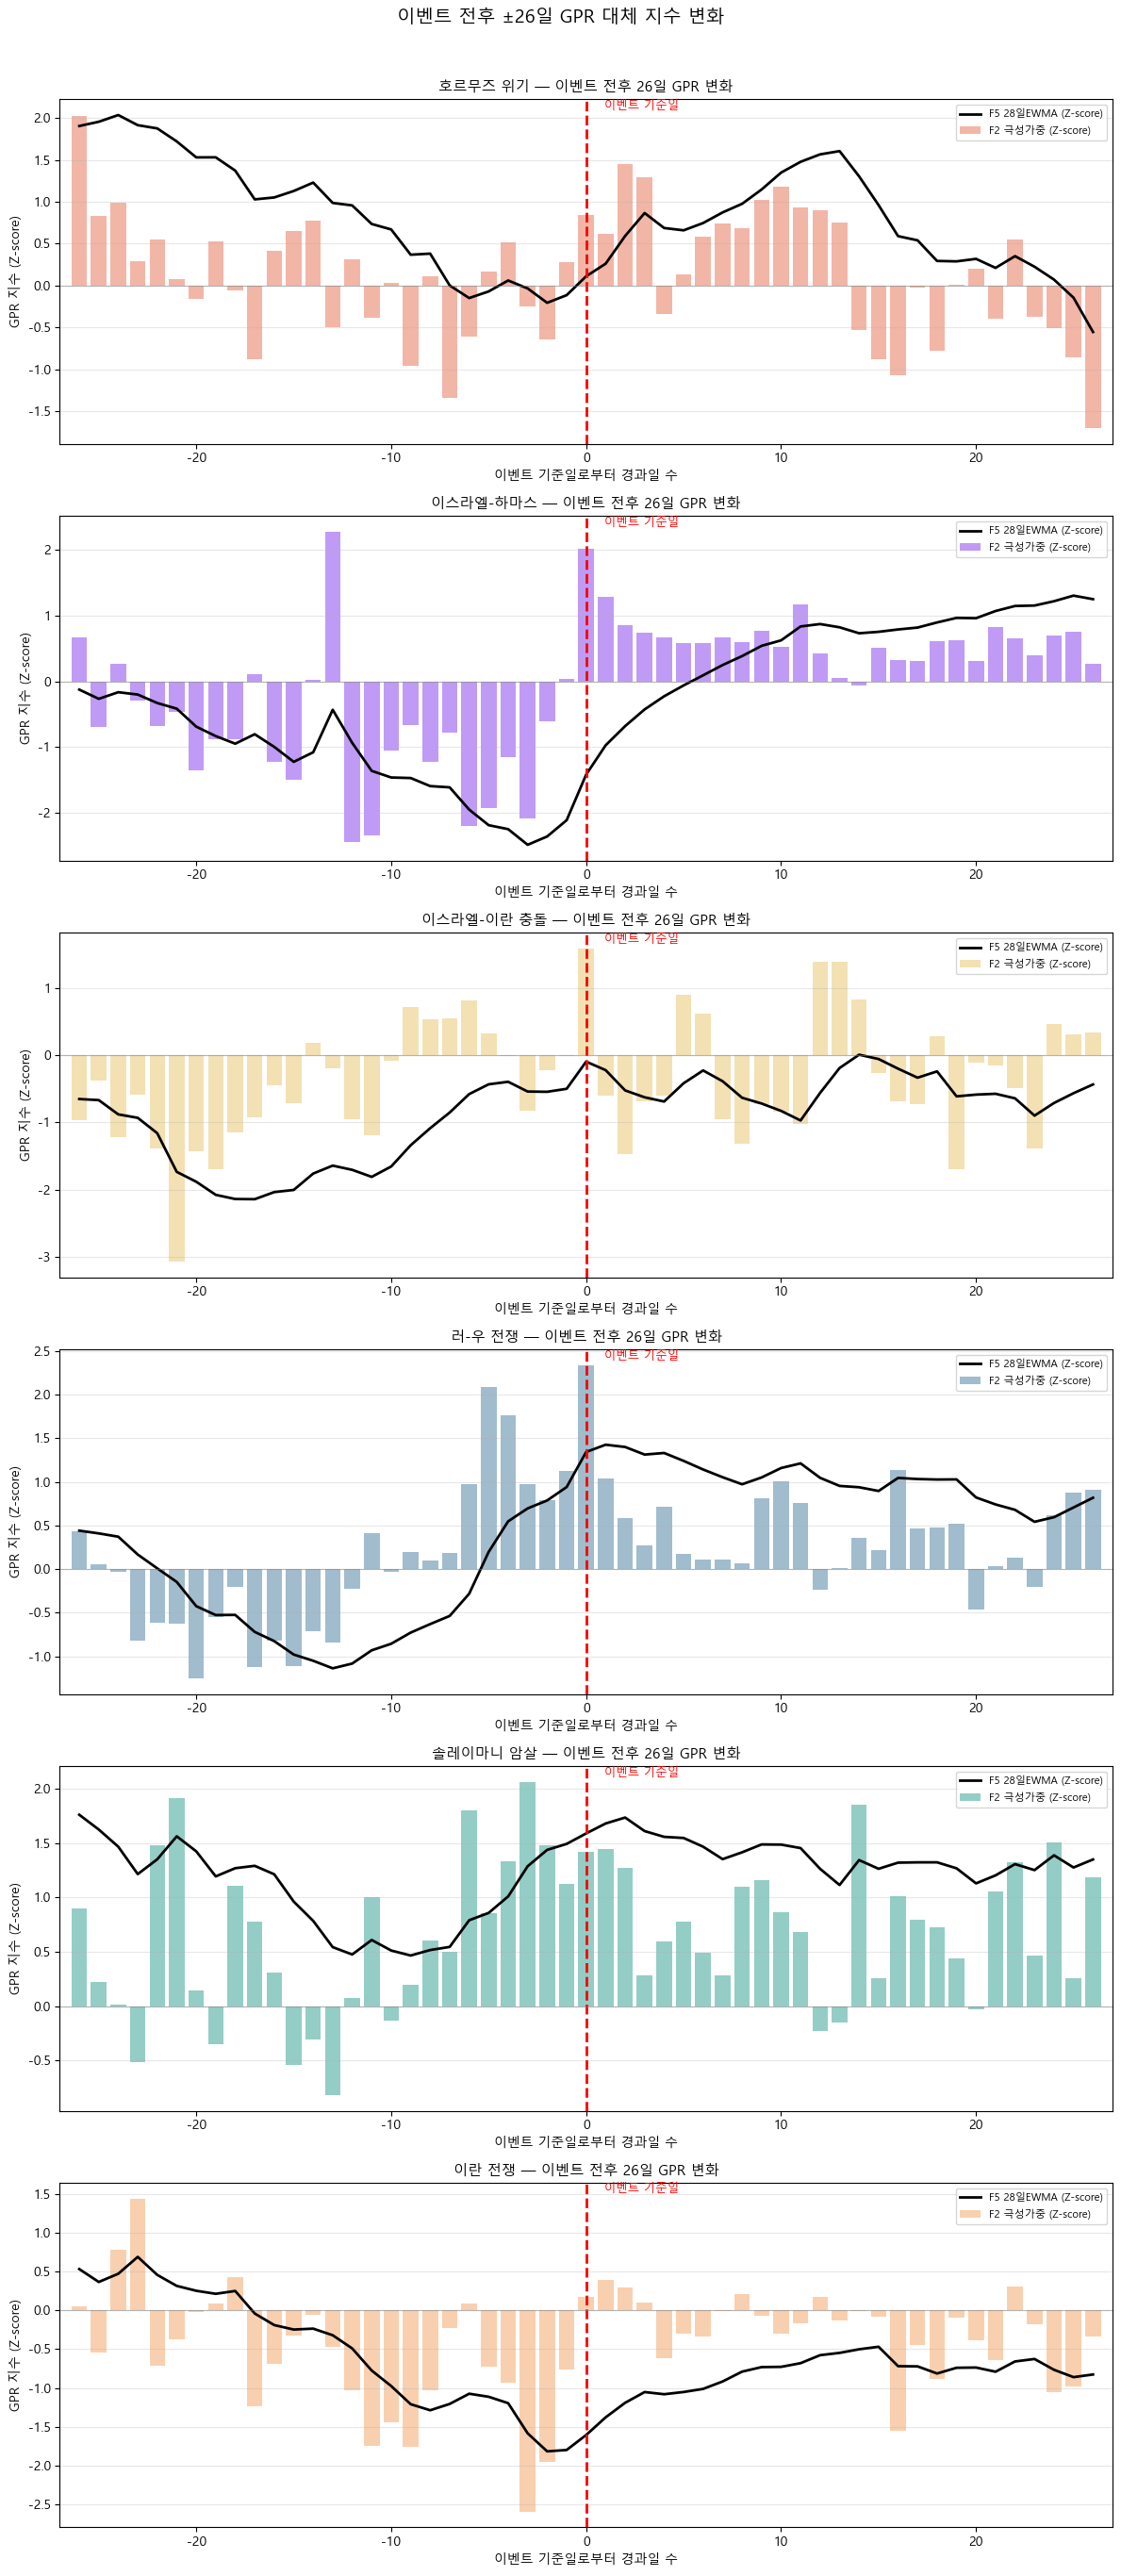

저장: 07_event_window.png


In [29]:
WINDOW = 26
n_events = len(merged_results)
fig, axes = plt.subplots(n_events, 1, figsize=(12, 4.5 * n_events))
if n_events == 1:
    axes = [axes]

for ax, (event, result) in zip(axes, merged_results.items()):
    result   = result.copy()
    result['date'] = pd.to_datetime(result['date'])
    result   = result.sort_values('date')
    event_dt = pd.Timestamp(EVENT_DATES[event])
    color    = COLORS.get(event, 'steelblue')

    result['day_offset'] = (result['date'] - event_dt).dt.days
    window_data = result[result['day_offset'].between(-WINDOW, WINDOW)].copy()

    ax.bar(window_data['day_offset'], window_data['F2_z'],
           color=color, alpha=0.5, label='F2 극성가중 (Z-score)')
    ax.plot(window_data['day_offset'], window_data['F5_z'],
            color='black', lw=2, label='F5 28일EWMA (Z-score)')

    ax.axvline(0, color='red', lw=2, ls='--')
    # BUG-7 동일 패턴 수정: get_xaxis_transform() 사용
    ax.text(0.5, 1.0, '  이벤트 기준일', color='red', fontsize=9,
            va='top', transform=ax.get_xaxis_transform())
    ax.axhline(0, color='gray', lw=0.8, alpha=0.5)

    ax.set_xlabel('이벤트 기준일로부터 경과일 수')
    ax.set_ylabel('GPR 지수 (Z-score)')
    ax.set_title(
        f'{EVENT_LABELS.get(event, event)} — 이벤트 전후 {WINDOW}일 GPR 변화',
        fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(-WINDOW - 1, WINDOW + 1)

plt.suptitle(f'이벤트 전후 ±{WINDOW}일 GPR 대체 지수 변화', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('07_event_window.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_event_window.png')

In [30]:
save_cols = [
    'date','event_name','event_date','N','mean_tone',
    'F1_raw','F2_raw','F3_raw','F4_raw','F5_raw',
    'F1_z','F2_z','F3_z','F4_z','F5_z',
]
if gpr_available:
    save_cols += ['GPR','GPR_zscore']

print('▶ 이벤트별 CSV 저장')
for event, result in merged_results.items():
    out_cols = [c for c in save_cols if c in result.columns]
    fname    = f'gpr_custom_{event}.csv'
    result[out_cols].to_csv(fname, index=False, encoding='utf-8-sig')
    print(f'  ✅ {fname}  ({len(result)}행)')

gpr_all_save = pd.concat(
    [r[[c for c in save_cols if c in r.columns]]
     for r in merged_results.values()],
    ignore_index=True)
gpr_all_save.to_csv('gpr_combined.csv', index=False, encoding='utf-8-sig')
print(f'\n  ✅ gpr_combined.csv  ({len(gpr_all_save)}행)')

if not corr_summary.empty:
    corr_summary.to_csv('gpr_correlation_summary.csv',
                        index=False, encoding='utf-8-sig')
    print('  ✅ gpr_correlation_summary.csv')

print('\n저장 완료')

▶ 이벤트별 CSV 저장
  ✅ gpr_custom_hormuz_crisis.csv  (265행)
  ✅ gpr_custom_israel_hamas_war.csv  (382행)
  ✅ gpr_custom_israel_iran.csv  (437행)
  ✅ gpr_custom_russia_ukraine_war.csv  (686행)
  ✅ gpr_custom_soleimani_assassination.csv  (492행)
  ✅ gpr_custom_us_israel_iran.csv  (393행)

  ✅ gpr_combined.csv  (2655행)
  ✅ gpr_correlation_summary.csv

저장 완료


In [1]:
import pandas as pd

# 1. 파일 불러오기
file_path = 'gpr_combined.csv'
df = pd.read_csv(file_path)

# 2. 날짜 컬럼을 datetime 형식으로 변환 (정확한 정렬을 위해 필수)
# 컬럼명이 'date'라고 가정합니다. 만약 다르면 실제 이름으로 수정하세요.
date_col = 'date' 
df[date_col] = pd.to_datetime(df[date_col])

# 3. 날짜 기준 오름차순 정렬
df = df.sort_values(by=date_col).reset_index(drop=True)

# 4. 동일한 파일명으로 다시 저장 (덮어쓰기)
# 인덱스는 저장하지 않고, 한글 깨짐 방지를 위해 utf-8-sig를 권장합니다.
df.to_csv(file_path, index=False, encoding='utf-8-sig')

print(f"✅ {file_path} 파일이 날짜순으로 정렬되어 다시 저장되었습니다.")
print(f"   기간: {df[date_col].min().date()} ~ {df[date_col].max().date()}")

✅ gpr_combined.csv 파일이 날짜순으로 정렬되어 다시 저장되었습니다.
   기간: 2019-01-01 ~ 2026-04-30
